# E12 · Solver gabungan STMAC dan penjalanan ulang eksperimen

Pemeriksaan kode menunjukkan solver STMAC yang dipakai sejak E3b (fungsi `stmac` di notebook 03b,
disalin ke `stmac_core.py` dan `stmac_scalable.py`) tidak meminimumkan objektif ruang-waktu pada
Persamaan (4). Langkah spasial di setiap timestamp hanya membaca nilai stasiun yang teramati, lalu
menimpa semua sel yang tidak teramati. Hasil langkah temporal ikut tertimpa, sehingga keluaran akhir
sama dengan interpolasi spasial per timestamp dan nilai $\alpha_t$ tidak mengubah apa pun.

Notebook ini mengganti solver tersebut dengan minimizer eksak objektif gabungan (`stmac_joint.py`),
lalu menjalankan ulang bagian eksperimen yang memuat STMAC:

1. diagnosis solver lama,
2. pemeriksaan solver gabungan,
3. E7 dengan 20 realisasi mask, termasuk Transformer,
4. sensitivitas rasio $\alpha_t/\alpha_s$ lewat validasi silang blok,
5. Transformer pada periode uji dengan 30 realisasi,
6. pembanding completion dan transfer peta restriksi (E9/E9B),
7. model ekonomi (E6/E10) beserta baseline naif yang dibatasi fisik,
8. jaringan satelit 2019 (E11),
9. waktu komputasi terhadap jumlah stasiun (E8),
10. rangkuman angka.

Hasil yang tidak bergantung pada STMAC (pure temporal, Transformer setahun penuh, low-rank, GRMF)
diambil dari berkas hasil sebelumnya karena mask-nya identik. Semua keluaran baru diberi awalan
`E12_` agar berkas lama tidak tertimpa. Modul proyek (`stmac_core`, `stmac_scalable`, `sky_tools`)
dipakai bila tersedia; bila tidak, notebook memakai fungsi cadangan di `stmac_rerun_utils.py` yang
kecocokannya diperiksa terhadap artefak tersimpan.

In [1]:
import os, sys, json, time, warnings, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12.5,
    "xtick.labelsize": 11.5, "ytick.labelsize": 11.5, "legend.fontsize": 11,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

HERE = Path.cwd().resolve()
for p in (HERE, HERE.parent, HERE / "notebooks"):
    if (p / "stmac_joint.py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import stmac_joint as sj
import stmac_rerun_utils as ru
import transformer_numpy as tn

DATA = ru.locate("data", "multistation_1999_cleaned.parquet")
ROOT = DATA.parent
RES = ROOT / "results"; RES.mkdir(exist_ok=True)
MODELS = ROOT / "models"
for p in (ROOT, ROOT / "notebooks"):
    if p.exists() and str(p) not in sys.path:
        sys.path.append(str(p))


def optional_import(name):
    try:
        return importlib.import_module(name)
    except Exception:
        return None


sc_proj = optional_import("stmac_core")
ss_proj = optional_import("stmac_scalable")
sk_proj = optional_import("sky_tools")

ALPHA_T, ALPHA_S = 10.0, 1.0          # bobot yang dipakai di naskah
RATIO = ALPHA_T / ALPHA_S
N_SEEDS = 20                           # E7
N_SEEDS_HELDOUT = 30                   # Transformer pada periode uji
N_SEEDS_E9 = 10                        # E9/E9B dan E11
SEL_SEED = 101
CV_HIDE_FRAC = 0.05
RATIO_GRID = [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]
KT_CLEAR, KT_CLOUDY = 0.85, 0.70
MDV_HW = 15                            # jendela klimatologi, +-hari
PT_CLIP = 1400.0                       # batas atas fisik untuk pure temporal yang dipotong
BLOCKS = sj.BLOCK_SPECS
LABEL = dict(BLOCKS)

multi = pd.read_parquet(DATA / "multistation_1999_cleaned.parquet")
STATIONS = json.load(open(DATA / "stations.json"))
CODES = list(STATIONS)
multi = multi[CODES]
LAT = np.array([STATIONS[c]["lat"] for c in CODES], float)
LON = np.array([STATIONS[c]["lon"] for c in CODES], float)
U_ALL = multi.to_numpy().T.astype(float)
N, T = U_ALL.shape
IDX = multi.index
DELTA = (LON - LON.mean()) / 15 * 60 / 5
L_G = np.load(DATA / "graph_L.npy")
L_TIME = sj.build_temporal_smoothness(T)
DAYTIME = (IDX.hour.values >= 8) & (IDX.hour.values <= 16)


def idn(x, nd=1):
    # angka dengan koma desimal dan titik ribuan
    s = f"{x:,.{nd}f}"
    return s.replace(",", "_").replace(".", ",").replace("_", ".")


def load_csv(name):
    p = RES / name
    return pd.read_csv(p) if p.exists() else None


def status(mod):
    return "tersedia" if mod is not None else "tidak ada (memakai cadangan)"


print(f"DATA    : {DATA}")
print(f"RESULTS : {RES}")
print(f"stmac_core     : {status(sc_proj)}")
print(f"stmac_scalable : {status(ss_proj)}")
print(f"sky_tools      : {status(sk_proj)}")
print(f"{N} stasiun | {T:,} timestamp | sel siang {DAYTIME.sum():,} | puncak {U_ALL.max():.1f} W/m2")

DATA    : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
RESULTS : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results
stmac_core     : tersedia
stmac_scalable : tersedia
sky_tools      : tersedia
11 stasiun | 101,805 timestamp | sel siang 38,730 | puncak 1961.5 W/m2


## 1. Diagnosis solver lama

Kita menjalankan solver lama apa adanya (`sj.stmac_legacy`, salinan persis fungsi 03b) pada dua
panjang blok dan dua jenis sheaf, masing-masing dengan $\alpha_t$ = 0,01, 10, dan 1000. Keluarannya
kita bandingkan dengan interpolasi spasial per timestamp (`pure_spatial`, untuk sheaf longitude
dihitung di koordinat waktu surya). Kita juga mencatat jumlah iterasi yang benar-benar berjalan dan
jumlah timestamp yang masih memakai estimasi temporal. Bila `stmac_core` tersedia, salinan ini
dicocokkan dengan kode proyek.

In [2]:
DIAG_OUT = RES / "E12_diagnosis_legacy.csv"
diag = []
for bl, lab in [(6, "30 min"), (864, "3 day")]:
    mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=0)
    ev = (~mask) & DAYTIME[None, :]
    for sheaf, delta in [("trivial", None), ("longitude", DELTA)]:
        t0 = time.time()
        U10, info = sj.stmac_legacy(U_ALL, mask, L_G, L_TIME, delta, 4, 10.0, 1.0, return_info=True)
        U_lo = sj.stmac_legacy(U_ALL, mask, L_G, L_TIME, delta, 4, 0.01, 1.0)
        U_hi = sj.stmac_legacy(U_ALL, mask, L_G, L_TIME, delta, 4, 1000.0, 1.0)
        if delta is None:
            U_sp = sj.pure_spatial(U_ALL, mask, L_G, 1.0)
        else:
            Zs, Ms = sj.to_solar_frame(U_ALL, mask, delta)
            U_sp = sj.from_solar_frame(sj.pure_spatial(Zs, Ms, L_G, 1.0), delta)
        U_j = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, delta, None, ALPHA_T, ALPHA_S)
        rec = dict(block_label=lab, block_len=bl, sheaf=sheaf,
                   rmse_legacy=sj.rmse(U_ALL, U10, ev),
                   maxdiff_alpha_t_0_01=float(np.abs(U_lo - U10)[ev].max()),
                   maxdiff_alpha_t_1000=float(np.abs(U_hi - U10)[ev].max()),
                   maxdiff_vs_pure_spatial=float(np.abs(U_sp - U10)[ev].max()),
                   iters=info["iters"], rel_change_last=info["rel_change"][-1],
                   timestamps_left_to_temporal=info["timestamps_left_to_temporal"],
                   rmse_joint=sj.rmse(U_ALL, U_j, ev))
        if sc_proj is not None:
            U_p = sc_proj.stmac(U_ALL, mask, L_G, L_TIME, delta, 4, 10.0, 1.0)
            rec["maxdiff_vs_stmac_core"] = float(np.abs(np.asarray(U_p) - U10).max())
        if ss_proj is not None:
            Y = np.where(mask, U_ALL, 0.0)
            a = np.asarray(ss_proj.stmac_scalable(Y, mask, L_G, L_TIME, delta, 4, 0.01, 1.0))
            b = np.asarray(ss_proj.stmac_scalable(Y, mask, L_G, L_TIME, delta, 4, 1000.0, 1.0))
            rec["scalable_maxdiff_alpha_t"] = float(np.abs(a - b)[ev].max())
        rec["sec"] = time.time() - t0
        diag.append(rec)
        print(f"{lab:>7s} {sheaf:9s} | lama {rec['rmse_legacy']:7.2f} | "
              f"selisih a_t 0,01/1000: {rec['maxdiff_alpha_t_0_01']:.1e}/{rec['maxdiff_alpha_t_1000']:.1e} | "
              f"vs pure_spatial {rec['maxdiff_vs_pure_spatial']:.1e} | iterasi {rec['iters']} | "
              f"gabungan {rec['rmse_joint']:7.2f} | {rec['sec']:.0f} s", flush=True)
DIAG = pd.DataFrame(diag)
ru.atomic_csv(DIAG, DIAG_OUT)

 30 min trivial   | lama  197.61 | selisih a_t 0,01/1000: 0.0e+00/0.0e+00 | vs pure_spatial 0.0e+00 | iterasi 2 | gabungan  116.39 | 43 s
 30 min longitude | lama  196.13 | selisih a_t 0,01/1000: 0.0e+00/0.0e+00 | vs pure_spatial 0.0e+00 | iterasi 2 | gabungan  116.58 | 52 s
  3 day trivial   | lama  204.05 | selisih a_t 0,01/1000: 0.0e+00/0.0e+00 | vs pure_spatial 0.0e+00 | iterasi 2 | gabungan  207.05 | 43 s
  3 day longitude | lama  202.08 | selisih a_t 0,01/1000: 0.0e+00/0.0e+00 | vs pure_spatial 0.0e+00 | iterasi 2 | gabungan  205.57 | 50 s


In [3]:
D = DIAG
inv = float(D[["maxdiff_alpha_t_0_01", "maxdiff_alpha_t_1000"]].to_numpy().max())
eqs = float(D.maxdiff_vs_pure_spatial.max())
print("INTERPRETASI DIAGNOSIS")
print("=" * 88)
if inv == 0.0:
    print(f"- Mengubah alpha_t dari 0,01 ke 1000 tidak mengubah satu sel pun pada {len(D)} kasus uji. "
          "Suku temporal tidak ikut menentukan keluaran solver lama.")
else:
    print(f"- alpha_t mengubah keluaran solver lama sampai {inv:.3g} W/m2, jadi suku temporal masih berperan.")
print(f"- Keluaran solver lama sama dengan interpolasi spasial per timestamp; selisih maksimumnya "
      f"{eqs:.1e} W/m2 (batas pembulatan angka mesin).")
print(f"- Perulangan berhenti pada iterasi ke-{int(D.iters.max())} dengan perubahan relatif terakhir "
      f"{D.rel_change_last.max():.1e}; timestamp yang masih memakai estimasi temporal: "
      f"{int(D.timestamps_left_to_temporal.max())}.")
for r in D.itertuples():
    print(f"- {r.block_label}, sheaf {r.sheaf}: solver lama {idn(r.rmse_legacy)} W/m2, "
          f"solver gabungan {idn(r.rmse_joint)} W/m2.")
if "maxdiff_vs_stmac_core" in D:
    print(f"- Salinan solver lama identik dengan stmac_core (selisih maksimum "
          f"{D.maxdiff_vs_stmac_core.max():.1e} W/m2).")
if "scalable_maxdiff_alpha_t" in D:
    print(f"- stmac_scalable juga tidak berubah terhadap alpha_t (selisih maksimum "
          f"{D.scalable_maxdiff_alpha_t.max():.1e} W/m2).")

INTERPRETASI DIAGNOSIS
- Mengubah alpha_t dari 0,01 ke 1000 tidak mengubah satu sel pun pada 4 kasus uji. Suku temporal tidak ikut menentukan keluaran solver lama.
- Keluaran solver lama sama dengan interpolasi spasial per timestamp; selisih maksimumnya 0.0e+00 W/m2 (batas pembulatan angka mesin).
- Perulangan berhenti pada iterasi ke-2 dengan perubahan relatif terakhir 0.0e+00; timestamp yang masih memakai estimasi temporal: 0.
- 30 min, sheaf trivial: solver lama 197,6 W/m2, solver gabungan 116,4 W/m2.
- 30 min, sheaf longitude: solver lama 196,1 W/m2, solver gabungan 116,6 W/m2.
- 3 day, sheaf trivial: solver lama 204,1 W/m2, solver gabungan 207,0 W/m2.
- 3 day, sheaf longitude: solver lama 202,1 W/m2, solver gabungan 205,6 W/m2.
- Salinan solver lama identik dengan stmac_core (selisih maksimum 0.0e+00 W/m2).
- stmac_scalable juga tidak berubah terhadap alpha_t (selisih maksimum 0.0e+00 W/m2).


## 2. Solver gabungan

Kita menulis ulang Persamaan (4) sebagai masalah berkendala. Sel teramati dikunci pada nilai
observasinya, dan yang dicari hanya sel yang tidak teramati:

$$\min_{U}\; \alpha_t \sum_{v}\lVert D_2 u_v\rVert_2^2 \;+\; \alpha_s \langle U, \Delta_{\mathcal F} U\rangle
\quad \text{dengan syarat}\quad M\odot U = M\odot U_{\mathrm{obs}}.$$

Pada bentuk ini hanya rasio $r=\alpha_t/\alpha_s$ yang menentukan solusi. Bobot di naskah
($\alpha_t=10$, $\alpha_s=1$) berarti $r=10$. Kondisi optimalitasnya berupa sistem linear simetris
definit positif berukuran jumlah sel yang tidak teramati, sekitar 10% dari $N\times T$. Kita merakit
sistem itu langsung tanpa membentuk produk Kronecker penuh, lalu menyelesaikannya dengan SuperLU.
Sheaf longitude diperlakukan sama seperti Algorithm 1: inisialisasi linear per stasiun, pergeseran
FFT sebesar $\delta_v$, mask digeser dengan pembulatan, solve di koordinat waktu surya, lalu digeser
balik.

Pemeriksaan di bawah mencakup residu KKT, invarian terhadap skala bobot, tidak adanya kebocoran isi
gap, pengaruh $\alpha_t$, dan pembanding brute-force pada subproblem kecil.

In [4]:
mask, _ = sj.build_block_mask(N, T, 72, 0.10, seed=0)
ev = (~mask) & DAYTIME[None, :]
U_a, info_a = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, None, None, 10.0, 1.0, return_info=True)
U_b = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, None, None, 100.0, 10.0)
U_e = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, 10.0, 1.0)
U_noise = U_ALL.copy(); U_noise[~mask] = 9999.0
U_c = sj.stmac_joint(U_noise, mask, L_G, L_TIME, None, None, 10.0, 1.0)
U_d = sj.stmac_joint(U_noise, mask, L_G, L_TIME, DELTA, None, 10.0, 1.0)

# pembanding brute-force: 4 stasiun, 3 hari, sistem padat
idxs = [0, 2, 4, 5]; Tb = 864
W_sub = np.load(DATA / "graph_W.npy")[np.ix_(idxs, idxs)]
Lg_sub = np.diag(W_sub.sum(1)) - W_sub
Lt_sub = sj.build_temporal_smoothness(Tb)
U_sub = U_ALL[idxs, :Tb]
M_sub, _ = sj.build_block_mask(4, Tb, 36, 0.2, seed=3)
U_js, _ = sj.solve_joint_clamped(np.where(M_sub, U_sub, 0.0), M_sub, Lg_sub, Lt_sub, 10.0)
Q = 10.0 * np.kron(np.eye(4), Lt_sub.toarray()) + np.kron(Lg_sub, np.eye(Tb))
mflat = M_sub.ravel(); mi = np.flatnonzero(~mflat); oi = np.flatnonzero(mflat)
x_bf = np.linalg.solve(Q[np.ix_(mi, mi)], -Q[np.ix_(mi, oi)] @ U_sub.ravel()[oi])

CHECKS = pd.DataFrame([
    ("residu KKT relatif (6 h, trivial)", sj.kkt_residual(U_a, mask, L_G, L_TIME, 10.0)),
    ("selisih maks (10,1) vs (100,10)", float(np.abs(U_a - U_b).max())),
    ("selisih maks bila isi gap = 9999, trivial", float(np.abs(U_c - U_a).max())),
    ("selisih maks bila isi gap = 9999, longitude", float(np.abs(U_d - U_e).max())),
    ("selisih maks vs brute-force padat", float(np.abs(U_js.ravel()[mi] - x_bf).max())),
    ("jumlah variabel (6 h)", float(info_a["n_unknowns"])),
    ("nnz matriks (6 h)", float(info_a["nnz"])),
    ("detik rakit + solve (6 h)", float(info_a["sec_build"] + info_a["sec_solve"])),
], columns=["pemeriksaan", "nilai"])
ru.atomic_csv(CHECKS, RES / "E12_solver_checks.csv")
print(CHECKS.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

AT_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]
at_rows = []
for a_t in AT_GRID:
    U_l = sj.stmac_legacy(U_ALL, mask, L_G, L_TIME, None, 4, a_t, 1.0)
    U_j = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, None, None, a_t, 1.0)
    at_rows.append({"alpha_t": a_t, "rmse_legacy": sj.rmse(U_ALL, U_l, ev),
                    "rmse_joint": sj.rmse(U_ALL, U_j, ev)})
AT = pd.DataFrame(at_rows)
ru.atomic_csv(AT, RES / "E12_alpha_t_effect.csv")
print()
print(AT.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))

                                pemeriksaan     nilai
          residu KKT relatif (6 h, trivial) 4.866e-14
            selisih maks (10,1) vs (100,10) 0.000e+00
  selisih maks bila isi gap = 9999, trivial 0.000e+00
selisih maks bila isi gap = 9999, longitude 0.000e+00
          selisih maks vs brute-force padat 4.832e-12
                      jumlah variabel (6 h) 1.070e+05
                          nnz matriks (6 h) 5.614e+05
                  detik rakit + solve (6 h) 2.603e-01

  alpha_t  rmse_legacy  rmse_joint
    0.010      187.009     191.746
    0.100      187.009     190.598
    1.000      187.009     188.017
   10.000      187.009     183.939
  100.000      187.009     178.753
 1000.000      187.009     177.164
10000.000      187.009     210.511


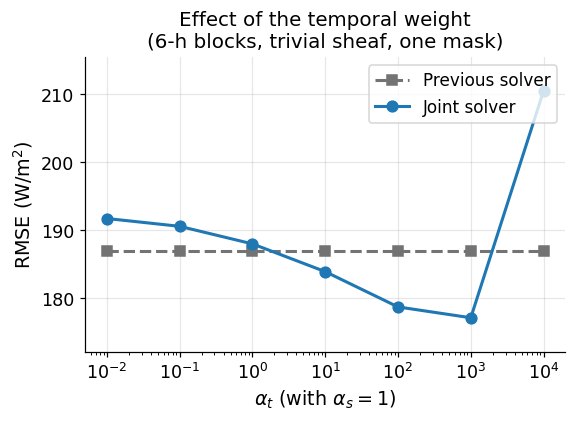

In [5]:
fig, ax = plt.subplots(figsize=(5.4, 4.0))
ax.plot(AT.alpha_t, AT.rmse_legacy, "s--", color="0.45", lw=2, ms=7, label="Previous solver")
ax.plot(AT.alpha_t, AT.rmse_joint, "o-", color="C0", lw=2, ms=7, label="Joint solver")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha_t$ (with $\alpha_s = 1$)")
ax.set_ylabel(r"RMSE (W/m$^2$)")
ax.set_title("Effect of the temporal weight\n(6-h blocks, trivial sheaf, one mask)")
ax.legend(loc="upper right", frameon=True)
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(RES / "E12_alpha_t_effect.png")
plt.show()

In [6]:
c = dict(zip(CHECKS["pemeriksaan"], CHECKS["nilai"]))
print("INTERPRETASI PEMERIKSAAN SOLVER")
print("=" * 88)
print(f"- Residu KKT relatif {c['residu KKT relatif (6 h, trivial)']:.1e}: solusi memenuhi kondisi optimalitas "
      "objektif berkendala sampai presisi mesin.")
print(f"- Mengalikan kedua bobot dengan 10 mengubah hasil paling banyak "
      f"{c['selisih maks (10,1) vs (100,10)']:.1e} W/m2; hanya rasio r yang berperan.")
leak = max(c['selisih maks bila isi gap = 9999, trivial'], c['selisih maks bila isi gap = 9999, longitude'])
print(f"- Mengganti isi gap dengan 9999 mengubah hasil paling banyak {leak:.1e} W/m2; solver tidak membaca "
      "nilai sel yang tidak teramati.")
print(f"- Selisih terhadap solusi brute-force padat {c['selisih maks vs brute-force padat']:.1e} W/m2.")
print(f"- Sistem 6 h berisi {idn(c['jumlah variabel (6 h)'], 0)} variabel dan diselesaikan dalam "
      f"{idn(c['detik rakit + solve (6 h)'], 2)} detik.")
rl = AT.rmse_legacy; rj = AT.rmse_joint
print(f"- Pada rentang alpha_t {idn(AT.alpha_t.min(), 2)} sampai {idn(AT.alpha_t.max(), 0)}, RMSE solver lama "
      f"berkisar {idn(rl.min(), 3)} sampai {idn(rl.max(), 3)} W/m2, sedangkan solver gabungan berkisar "
      f"{idn(rj.min())} sampai {idn(rj.max())} W/m2 dengan nilai terendah pada alpha_t = "
      f"{idn(AT.alpha_t[rj.idxmin()], 2)}.")

INTERPRETASI PEMERIKSAAN SOLVER
- Residu KKT relatif 4.9e-14: solusi memenuhi kondisi optimalitas objektif berkendala sampai presisi mesin.
- Mengalikan kedua bobot dengan 10 mengubah hasil paling banyak 0.0e+00 W/m2; hanya rasio r yang berperan.
- Mengganti isi gap dengan 9999 mengubah hasil paling banyak 0.0e+00 W/m2; solver tidak membaca nilai sel yang tidak teramati.
- Selisih terhadap solusi brute-force padat 4.8e-12 W/m2.
- Sistem 6 h berisi 107.006 variabel dan diselesaikan dalam 0,26 detik.
- Pada rentang alpha_t 0,01 sampai 10.000, RMSE solver lama berkisar 187,009 sampai 187,009 W/m2, sedangkan solver gabungan berkisar 177,2 sampai 210,5 W/m2 dengan nilai terendah pada alpha_t = 1.000,00.


## 3. E7 diulang dengan solver gabungan

Protokolnya sama dengan E7: 20 realisasi mask, 10% sel per stasiun hilang sebagai blok kontigu,
RMSE dihitung pada sel siang (08:00 sampai 16:00) yang tidak teramati. Pure temporal, solver lama,
dan Transformer setahun penuh diambil dari `E7_replicates_raw.csv` dan
`E7TF_transformer_replicates.csv` karena mask-nya identik. Bila berkas itu tidak ada, nilainya
dihitung ulang.

Kita menambahkan dua baseline naif yang nilainya tetap dalam rentang fisik. Yang pertama pure
temporal yang dipotong ke 0 sampai 1400 W/m². Yang kedua klimatologi stasiun (mean diurnal
variation, MDV): sel yang hilang diisi rata-rata nilai teramati stasiun itu pada jam yang sama dalam
jendela ±15 hari. Keduanya hanya membaca sel teramati.

In [7]:
E7_OLD = load_csv("E7_replicates_raw.csv")
TF_OLD = load_csv("E7TF_transformer_replicates.csv")
OUT7 = RES / "E12_E7J_raw.csv"
rows = pd.read_csv(OUT7).to_dict("records") if OUT7.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
t_start = time.time()
for seed in range(N_SEEDS):
    for bl, lab in BLOCKS:
        if (seed, bl) in done:
            continue
        mask, n_blk = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        rec = {"seed": seed, "block_len": bl, "block_label": lab, "n_blocks": n_blk,
               "n_eval": int(ev.sum())}
        for name, delta in [("joint_trivial", None), ("joint_longitude", DELTA)]:
            U_r, info = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, delta, None, ALPHA_T, ALPHA_S,
                                       return_info=True)
            rec["rmse_" + name] = sj.rmse(U_ALL, U_r, ev)
            rec["mae_" + name] = float(np.mean(np.abs(U_ALL[ev] - U_r[ev])))
            rec["sec_" + name] = info["sec_total"]
        C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
        rec["rmse_climatology"] = sj.rmse(U_ALL, np.where(mask, U_ALL, C), ev)
        U_pt = sj.pure_temporal(U_ALL, mask, L_TIME, 10.0)
        rec["rmse_pt_clipped"] = sj.rmse(U_ALL, np.clip(U_pt, 0.0, PT_CLIP), ev)
        if E7_OLD is None:
            rec["rmse_pure_temporal"] = sj.rmse(U_ALL, U_pt, ev)
            for name, delta in [("legacy_trivial", None), ("legacy_longitude", DELTA)]:
                rec["rmse_" + name] = sj.rmse(
                    U_ALL, sj.stmac_legacy(U_ALL, mask, L_G, L_TIME, delta, 4, 10.0, 1.0), ev)
        rows.append(rec)
        ru.atomic_csv(pd.DataFrame(rows), OUT7)
    print(f"seed {seed:2d} selesai | {(time.time() - t_start) / 60:.1f} menit", flush=True)

E7J = pd.DataFrame(rows).sort_values(["block_len", "seed"]).reset_index(drop=True)
if E7_OLD is not None:
    old = E7_OLD.rename(columns={"rmse_stmac_trivial": "rmse_legacy_trivial",
                                 "rmse_stmac_longitude": "rmse_legacy_longitude"})
    E7J = E7J.merge(old[["seed", "block_len", "rmse_pure_temporal", "rmse_legacy_trivial",
                         "rmse_legacy_longitude"]], on=["seed", "block_len"], how="left")
if TF_OLD is not None:
    E7J = E7J.merge(TF_OLD[["seed", "block_len", "rmse_transformer"]],
                    on=["seed", "block_len"], how="left")
assert E7J.groupby("block_len").size().eq(N_SEEDS).all(), "grid tidak lengkap"
print(f"{len(E7J)} baris = {E7J.seed.nunique()} seed x {E7J.block_len.nunique()} panjang blok")

seed  0 selesai | 9.7 menit
seed  1 selesai | 10.1 menit
seed  2 selesai | 19.8 menit
seed  3 selesai | 20.2 menit
seed  4 selesai | 21.4 menit
seed  5 selesai | 21.9 menit
seed  6 selesai | 22.3 menit
seed  7 selesai | 22.9 menit
seed  8 selesai | 23.3 menit
seed  9 selesai | 23.7 menit
seed 10 selesai | 24.1 menit
seed 11 selesai | 24.4 menit
seed 12 selesai | 24.8 menit
seed 13 selesai | 25.2 menit
seed 14 selesai | 25.6 menit
seed 15 selesai | 26.0 menit
seed 16 selesai | 26.4 menit
seed 17 selesai | 26.8 menit
seed 18 selesai | 27.1 menit
seed 19 selesai | 27.5 menit
140 baris = 20 seed x 7 panjang blok


In [8]:
if "rmse_transformer" not in E7J or E7J.rmse_transformer.isna().any():
    raise RuntimeError("Nilai Transformer setahun penuh belum ada. Jalankan 09a atau bagian 5 "
                       "dengan rekonstruksi setahun penuh.")

M7 = ["pure_temporal", "pt_clipped", "climatology", "transformer", "legacy_longitude",
      "joint_trivial", "joint_longitude"]
srows = []
for bl, g in E7J.groupby("block_len", sort=True):
    r = {"block_len": bl, "label": LABEL[bl], "n": len(g)}
    for m in M7:
        mu, lo, hi = ru.ci95(g["rmse_" + m])
        r[m], r[m + "_lo"], r[m + "_hi"] = mu, lo, hi
    srows.append(r)
S7 = pd.DataFrame(srows)
ru.atomic_csv(S7, RES / "E12_E7J_summary_ci.csv")

piv = E7J.pivot(index="seed", columns="block_len")
grow = []
for m in M7:
    g = (piv[("rmse_" + m, 2016)] / piv[("rmse_" + m, 6)]).to_numpy()
    mu, lo, hi = ru.ci95(g)
    grow.append({"method": m, "growth": mu, "ci_lo": lo, "ci_hi": hi})
G7 = pd.DataFrame(grow)
ru.atomic_csv(G7, RES / "E12_E7J_growth.csv")

FAM = [("joint_trivial", "joint_longitude"), ("pure_temporal", "joint_longitude"),
       ("pt_clipped", "joint_longitude"), ("climatology", "joint_longitude"),
       ("transformer", "joint_longitude"), ("legacy_longitude", "joint_longitude")]
T7 = pd.concat([ru.paired_family(E7J, a, b) for a, b in FAM], ignore_index=True)
ru.atomic_csv(T7, RES / "E12_E7J_tests.csv")

print(f"RMSE (W/m2), rata-rata {N_SEEDS} realisasi")
print(S7[["label"] + M7].to_string(index=False, float_format=lambda v: f"{v:9.1f}"))
print("\nFaktor pertumbuhan 30 menit ke 7 hari")
print(G7.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))
print("\nUji berpasangan (selisih = a - b; positif berarti b lebih baik)")
print(T7[["a", "b", "label", "mean_diff", "ci_lo", "ci_hi", "wins_b", "n", "p_holm"]]
      .to_string(index=False, float_format=lambda v: f"{v:9.3g}"))

RMSE (W/m2), rata-rata 20 realisasi
 label  pure_temporal  pt_clipped  climatology  transformer  legacy_longitude  joint_trivial  joint_longitude
30 min           69.6        72.4        162.0        153.0             195.7          114.5            114.3
   2 h          113.7       112.1        162.5        165.6             195.8          182.9            182.5
   6 h          239.4       201.4        163.2        201.3             195.2          192.9            192.5
  12 h          445.4       369.4        162.1        219.0             194.8          195.0            194.8
 1 day          726.7       570.7        160.8        229.9             194.3          196.0            195.6
 3 day         1904.4       657.6        166.2        250.7             199.7          202.8            202.3
 7 day         4961.2       695.3        169.1        251.8             196.3          199.7            199.6

Faktor pertumbuhan 30 menit ke 7 hari
          method  growth   ci_lo   ci_hi
   p

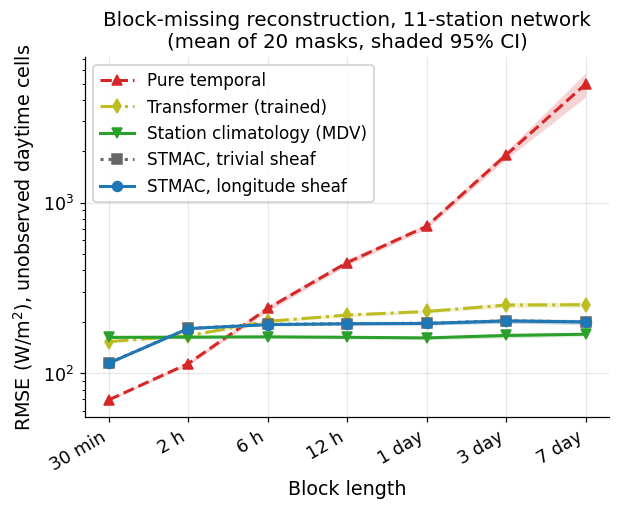

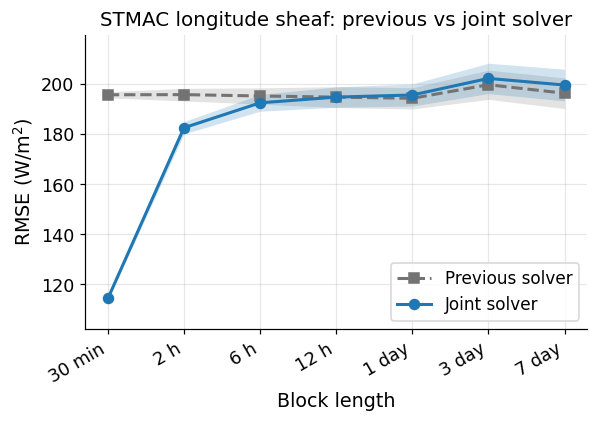

In [9]:
x = np.arange(len(S7))
fig, ax = plt.subplots(figsize=(5.8, 4.8))
STY7 = [("pure_temporal", "Pure temporal", "C3", "--", "^"),
        ("transformer", "Transformer (trained)", "C8", "-.", "d"),
        ("climatology", "Station climatology (MDV)", "C2", "-", "v"),
        ("joint_trivial", "STMAC, trivial sheaf", "0.40", ":", "s"),
        ("joint_longitude", "STMAC, longitude sheaf", "C0", "-", "o")]
for col, name, c, ls, mk in STY7:
    ax.plot(x, S7[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, np.maximum(S7[col + "_lo"], 1.0), S7[col + "_hi"], color=c, alpha=0.2, lw=0)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(S7.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$), unobserved daytime cells")
ax.set_title(f"Block-missing reconstruction, 11-station network\n(mean of {N_SEEDS} masks, shaded 95% CI)")
ax.legend(loc="upper left", frameon=True, framealpha=0.95)
fig.tight_layout()
fig.savefig(RES / "E12_block_sweep_4methods.png")
plt.show()

fig, ax = plt.subplots(figsize=(5.6, 4.0))
for col, name, c, ls, mk in [("legacy_longitude", "Previous solver", "0.45", "--", "s"),
                             ("joint_longitude", "Joint solver", "C0", "-", "o")]:
    ax.plot(x, S7[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, S7[col + "_lo"], S7[col + "_hi"], color=c, alpha=0.2, lw=0)
ax.set_xticks(x)
ax.set_xticklabels(S7.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$)")
ax.set_title("STMAC longitude sheaf: previous vs joint solver")
ax.legend(loc="lower right", frameon=True)
ax.margins(y=0.12)
fig.tight_layout()
fig.savefig(RES / "E12_legacy_vs_joint.png")
plt.show()

In [10]:
def fam(a, b, table):
    return table[(table.a == a) & (table.b == b)].set_index("label")


def describe_vs(a, b, table, name_b, name_a):
    t = fam(a, b, table)
    better = [l for l, r in t.iterrows() if r.mean_diff > 0 and r.p_holm < 0.05]
    worse = [l for l, r in t.iterrows() if r.mean_diff < 0 and r.p_holm < 0.05]
    ns = [l for l, r in t.iterrows() if r.p_holm >= 0.05]
    out = []
    if better:
        out.append(f"{name_b} lebih baik secara signifikan pada {', '.join(better)}")
    if worse:
        out.append(f"{name_a} lebih baik secara signifikan pada {', '.join(worse)}")
    if ns:
        out.append(f"tidak berbeda signifikan pada {', '.join(ns)}")
    return "; ".join(out)


s = S7.set_index("label")
g = G7.set_index("method")
print("INTERPRETASI E7 DENGAN SOLVER GABUNGAN")
print("=" * 88)
print("- STMAC longitude (solver gabungan, r = 10): "
      + ", ".join(f"{l} {idn(v)}" for l, v in s.joint_longitude.items()) + " W/m2.")
print("- Solver lama pada mask yang sama: "
      + ", ".join(f"{l} {idn(v)}" for l, v in s.legacy_longitude.items()) + " W/m2.")
print(f"- Faktor pertumbuhan 30 menit ke 7 hari: solver gabungan {idn(g.loc['joint_longitude', 'growth'], 2)} kali "
      f"(CI {idn(g.loc['joint_longitude', 'ci_lo'], 2)} sampai {idn(g.loc['joint_longitude', 'ci_hi'], 2)}), "
      f"solver lama {idn(g.loc['legacy_longitude', 'growth'], 2)} kali, Transformer "
      f"{idn(g.loc['transformer', 'growth'], 2)} kali, pure temporal {idn(g.loc['pure_temporal', 'growth'], 1)} kali.")
pt = fam("pure_temporal", "joint_longitude", T7)
first = [l for l, r in pt.iterrows() if r.mean_diff > 0]
print(f"- Terhadap pure temporal: {describe_vs('pure_temporal', 'joint_longitude', T7, 'STMAC', 'pure temporal')}. "
      f"Blok terpendek tempat STMAC unggul: {first[0] if first else 'tidak ada'}.")
print("- Klimatologi stasiun (MDV): "
      + ", ".join(f"{l} {idn(v)}" for l, v in s.climatology.items()) + " W/m2.")
print(f"- Terhadap klimatologi stasiun: "
      f"{describe_vs('climatology', 'joint_longitude', T7, 'STMAC', 'klimatologi')}.")
print(f"- Terhadap pure temporal yang dipotong ke 0 sampai {idn(PT_CLIP, 0)} W/m2: "
      f"{describe_vs('pt_clipped', 'joint_longitude', T7, 'STMAC', 'PT terpotong')}.")
print(f"- Terhadap Transformer (evaluasi setahun penuh): "
      f"{describe_vs('transformer', 'joint_longitude', T7, 'STMAC', 'Transformer')}.")
print(f"- Terhadap solver lama: {describe_vs('legacy_longitude', 'joint_longitude', T7, 'solver gabungan', 'solver lama')}.")
lt = fam("joint_trivial", "joint_longitude", T7)
nsig = int((lt.p_holm < 0.05).sum())
print(f"- Sheaf longitude dibanding trivial (solver gabungan): selisih {idn(lt.mean_diff.min(), 2)} sampai "
      f"{idn(lt.mean_diff.max(), 2)} W/m2, signifikan pada {nsig} dari {len(lt)} panjang blok setelah koreksi Holm.")

INTERPRETASI E7 DENGAN SOLVER GABUNGAN
- STMAC longitude (solver gabungan, r = 10): 30 min 114,3, 2 h 182,5, 6 h 192,5, 12 h 194,8, 1 day 195,6, 3 day 202,3, 7 day 199,6 W/m2.
- Solver lama pada mask yang sama: 30 min 195,7, 2 h 195,8, 6 h 195,2, 12 h 194,8, 1 day 194,3, 3 day 199,7, 7 day 196,3 W/m2.
- Faktor pertumbuhan 30 menit ke 7 hari: solver gabungan 1,75 kali (CI 1,69 sampai 1,80), solver lama 1,00 kali, Transformer 1,65 kali, pure temporal 71,2 kali.
- Terhadap pure temporal: STMAC lebih baik secara signifikan pada 6 h, 12 h, 1 day, 3 day, 7 day; pure temporal lebih baik secara signifikan pada 30 min, 2 h. Blok terpendek tempat STMAC unggul: 6 h.
- Klimatologi stasiun (MDV): 30 min 162,0, 2 h 162,5, 6 h 163,2, 12 h 162,1, 1 day 160,8, 3 day 166,2, 7 day 169,1 W/m2.
- Terhadap klimatologi stasiun: STMAC lebih baik secara signifikan pada 30 min; klimatologi lebih baik secara signifikan pada 2 h, 6 h, 12 h, 1 day, 3 day, 7 day.
- Terhadap pure temporal yang dipotong ke 0 sampai 1

## 4. Sensitivitas rasio $\alpha_t/\alpha_s$ lewat validasi silang blok

Rasio $r=10$ diwarisi dari naskah. Untuk menilai apakah rasio lain lebih tepat tanpa menyentuh isi
gap yang dievaluasi, kita menyembunyikan blok tambahan (5% sel) dari sel yang masih teramati, dengan
panjang blok yang sama dengan skenario yang diuji. Solver dijalankan pada sisa sel teramati dan
dinilai pada blok yang disembunyikan. Rasio dipilih dua cara: satu rasio untuk semua panjang blok
(rata-rata galat validasi terendah) dan satu rasio per panjang blok. Keduanya lalu dievaluasi pada
20 realisasi mask E7.

In [11]:
CV_OUT = RES / "E12_ratio_cv.csv"
if CV_OUT.exists():
    CV = pd.read_csv(CV_OUT)
else:
    recs = []
    for bl, lab in BLOCKS:
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=SEL_SEED)
        fit_mask, hidden = sj.block_cv_mask(mask, bl, CV_HIDE_FRAC, seed=SEL_SEED + 7919)
        score = hidden & DAYTIME[None, :]
        for r in RATIO_GRID:
            U_r = sj.stmac_joint(U_ALL, fit_mask, L_G, L_TIME, DELTA, None, r, 1.0)
            recs.append({"block_len": bl, "block_label": lab, "ratio": r,
                         "cv_rmse": sj.rmse(U_ALL, U_r, score), "n_scored": int(score.sum())})
        print(f"{lab:>7s} selesai", flush=True)
    CV = pd.DataFrame(recs)
    ru.atomic_csv(CV, CV_OUT)

pooled = CV.groupby("ratio").cv_rmse.mean()
R_CV = float(pooled.idxmin())
R_BLOCK = {int(bl): float(g.loc[g.cv_rmse.idxmin(), "ratio"]) for bl, g in CV.groupby("block_len")}
print(CV.pivot(index="ratio", columns="block_label", values="cv_rmse")[[l for _, l in BLOCKS]]
      .to_string(float_format=lambda v: f"{v:8.1f}"))
print(f"\nRasio terpilih (satu untuk semua blok): r = {R_CV:g}")
print("Rasio terpilih per blok:", {LABEL[k]: v for k, v in R_BLOCK.items()})

EV_OUT = RES / "E12_ratio_cv_eval.csv"
rows = pd.read_csv(EV_OUT).to_dict("records") if EV_OUT.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
for seed in range(N_SEEDS):
    for bl, lab in BLOCKS:
        if (seed, bl) in done:
            continue
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        rec = {"seed": seed, "block_len": bl, "block_label": lab}
        cache = {RATIO: None}
        for tag, r in [("rcv", R_CV), ("rblock", R_BLOCK[bl])]:
            if r == RATIO:
                rec["rmse_joint_" + tag] = float(E7J[(E7J.seed == seed) & (E7J.block_len == bl)]
                                                 .rmse_joint_longitude.iloc[0])
                continue
            if cache.get(r) is None:
                cache[r] = sj.rmse(U_ALL, sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, r, 1.0), ev)
            rec["rmse_joint_" + tag] = cache[r]
        rows.append(rec)
        ru.atomic_csv(pd.DataFrame(rows), EV_OUT)
RCV = pd.DataFrame(rows).merge(
    E7J[["seed", "block_len", "rmse_joint_longitude", "rmse_transformer", "rmse_pure_temporal"]],
    on=["seed", "block_len"])
T_rcv = pd.concat([ru.paired_family(RCV, "joint_longitude", "joint_rcv"),
                   ru.paired_family(RCV, "transformer", "joint_rcv"),
                   ru.paired_family(RCV, "joint_longitude", "joint_rblock"),
                   ru.paired_family(RCV, "transformer", "joint_rblock")], ignore_index=True)
ru.atomic_csv(T_rcv, RES / "E12_ratio_cv_tests.csv")
S_rcv = RCV.groupby("block_len")[["rmse_joint_longitude", "rmse_joint_rcv", "rmse_joint_rblock",
                                  "rmse_transformer"]].mean()
S_rcv.index = [LABEL[b] for b in S_rcv.index]
print(f"\nRMSE rata-rata {N_SEEDS} realisasi (W/m2)")
print(S_rcv.to_string(float_format=lambda v: f"{v:8.1f}"))

 30 min selesai
    2 h selesai
    6 h selesai
   12 h selesai
  1 day selesai
  3 day selesai
  7 day selesai
block_label   30 min      2 h      6 h     12 h    1 day    3 day    7 day
ratio                                                                     
1.0            170.5    195.1    205.8    203.4    187.8    175.0    205.8
3.0            147.7    190.6    204.1    202.3    186.7    174.5    205.4
10.0           115.2    184.3    201.7    200.9    185.3    173.8    204.8
30.0            95.0    177.2    198.9    199.3    183.9    173.3    204.3
100.0           89.5    167.7    195.4    197.6    181.9    172.7    203.7
300.0           90.6    157.7    192.1    196.6    179.9    172.4    203.2
1000.0          92.5    158.8    189.8    197.4    177.7    172.4    202.7
3000.0          93.4    183.4    191.7    203.0    176.6    173.3    202.2
10000.0         93.9    211.7    205.4    221.4    179.0    176.4    201.9

Rasio terpilih (satu untuk semua blok): r = 1000
Rasio terpili

In [12]:
print("INTERPRETASI SENSITIVITAS RASIO")
print("=" * 88)
best_per = CV.loc[CV.groupby("block_len").cv_rmse.idxmin()]
print(f"- Validasi silang blok memilih r = {idn(R_CV, 0)} sebagai rasio tunggal. Pilihan per blok: "
      + ", ".join(f"{LABEL[int(r.block_len)]} r = {idn(r.ratio, 0)}" for r in best_per.itertuples()) + ".")
pen = (CV[CV.ratio == RATIO].set_index("block_len").cv_rmse
       / CV.groupby("block_len").cv_rmse.min() - 1) * 100
print(f"- Pada data validasi, r = 10 lebih buruk {idn(pen.min())} sampai {idn(pen.max())} persen "
      "dibanding rasio terbaik per blok.")
for tag, name in [("rcv", f"r = {idn(R_CV, 0)}"), ("rblock", "r per blok")]:
    t = T_rcv[(T_rcv.a == "joint_longitude") & (T_rcv.b == "joint_" + tag)]
    better = [r.label for r in t.itertuples() if r.mean_diff > 0 and r.p_holm < 0.05]
    worse = [r.label for r in t.itertuples() if r.mean_diff < 0 and r.p_holm < 0.05]
    print(f"- {name} dibanding r = 10 pada 20 realisasi: lebih baik signifikan di "
          f"{', '.join(better) if better else 'tidak ada blok'}; lebih buruk signifikan di "
          f"{', '.join(worse) if worse else 'tidak ada blok'}.")
    t2 = T_rcv[(T_rcv.a == "transformer") & (T_rcv.b == "joint_" + tag)]
    win = [r.label for r in t2.itertuples() if r.mean_diff > 0 and r.p_holm < 0.05]
    lose = [r.label for r in t2.itertuples() if r.mean_diff < 0 and r.p_holm < 0.05]
    print(f"  Terhadap Transformer: STMAC unggul signifikan di {', '.join(win) if win else 'tidak ada blok'}; "
          f"Transformer unggul signifikan di {', '.join(lose) if lose else 'tidak ada blok'}.")

INTERPRETASI SENSITIVITAS RASIO
- Validasi silang blok memilih r = 1.000 sebagai rasio tunggal. Pilihan per blok: 30 min r = 100, 2 h r = 300, 6 h r = 1.000, 12 h r = 300, 1 day r = 3.000, 3 day r = 300, 7 day r = 10.000.
- Pada data validasi, r = 10 lebih buruk 0,8 sampai 28,8 persen dibanding rasio terbaik per blok.
- r = 1.000 dibanding r = 10 pada 20 realisasi: lebih baik signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; lebih buruk signifikan di tidak ada blok.
  Terhadap Transformer: STMAC unggul signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; Transformer unggul signifikan di tidak ada blok.
- r per blok dibanding r = 10 pada 20 realisasi: lebih baik signifikan di 30 min, 2 h, 6 h, 12 h, 3 day, 7 day; lebih buruk signifikan di tidak ada blok.
  Terhadap Transformer: STMAC unggul signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; Transformer unggul signifikan di tidak ada blok.


## 4b. STMAC pada anomali terhadap klimatologi stasiun (eksploratif)

Bagian 3 memperlihatkan seberapa kuat klimatologi stasiun sebagai pembanding. Kita menguji varian
yang menggabungkan keduanya: solver gabungan merekonstruksi anomali $U - C$, dengan $C$ profil MDV
yang dihitung hanya dari sel teramati, lalu $C$ ditambahkan kembali. Suku ridge $\gamma$ menyusutkan
anomali di sel yang tidak teramati ke nol, sehingga pada gap panjang dengan informasi tetangga yang
lemah hasilnya mendekati klimatologi. Pasangan $(r,\gamma)$ dipilih sekali lewat validasi silang
blok pada sel teramati (prosedur yang sama dengan bagian 4), lalu dievaluasi pada 20 realisasi E7.
Varian ini belum tercantum di naskah; bagian ini menjadi bahan keputusan metodologis.

 30 min selesai
    2 h selesai
    6 h selesai
   12 h selesai
  1 day selesai
  3 day selesai
  7 day selesai
block_label    30 min     2 h     6 h    12 h   1 day   3 day   7 day
ratio   ridge                                                        
10.0    0.0     105.7   158.7   176.8   186.2   167.7   153.5   197.2
        0.3     108.1   153.3   169.4   179.0   159.5   146.8   185.6
        1.0     114.4   150.3   163.9   174.4   154.3   142.8   177.1
        3.0     127.0   150.9   161.6   173.0   153.1   142.6   173.4
        10.0    142.5   154.2   162.1   173.9   154.6   144.6   173.2
        30.0    152.6   156.9   163.0   174.8   155.7   145.9   173.6
100.0   0.0      88.2   147.2   171.5   183.3   164.8   152.2   196.1
        0.3      87.9   143.9   165.0   176.8   157.3   145.9   184.9
        1.0      87.9   142.2   160.3   172.6   152.6   142.3   176.8
        3.0      90.1   143.6   158.6   171.6   151.8   142.3   173.2
        10.0    102.2   147.9   159.7   172.7   

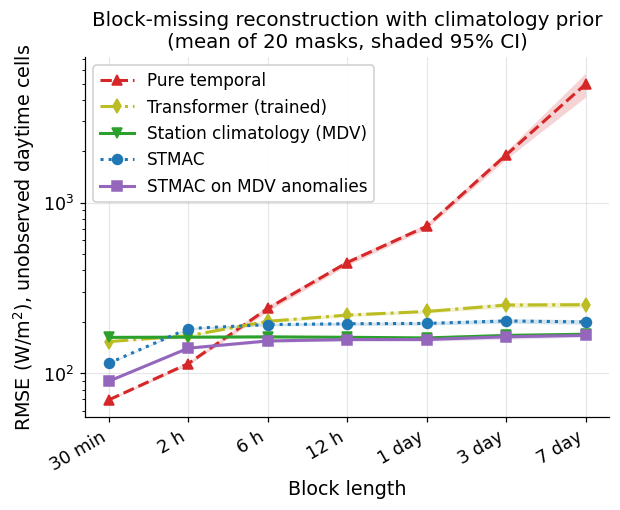

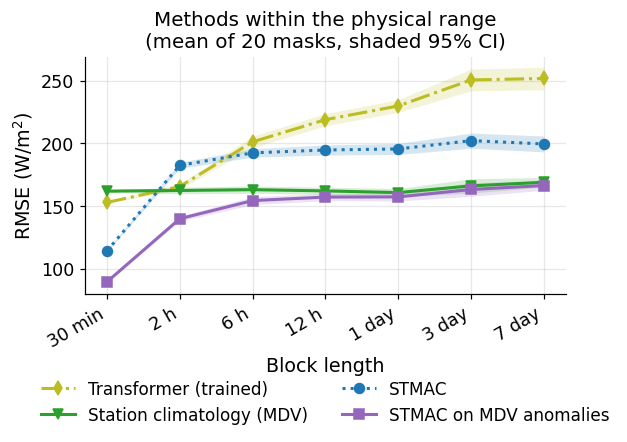

In [13]:
AN_GRID = [(r, g) for r in (10.0, 100.0, 1000.0, 10000.0) for g in (0.0, 0.3, 1.0, 3.0, 10.0, 30.0)]
AN_CV_OUT = RES / "E12_anomaly_cv.csv"
if AN_CV_OUT.exists():
    ANCV = pd.read_csv(AN_CV_OUT)
else:
    recs = []
    for bl, lab in BLOCKS:
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=SEL_SEED)
        fit_mask, hidden = sj.block_cv_mask(mask, bl, CV_HIDE_FRAC, seed=SEL_SEED + 7919)
        score = hidden & DAYTIME[None, :]
        C_fit = ru.mdv_field(U_ALL, fit_mask, IDX, MDV_HW)
        recs.append({"block_len": bl, "block_label": lab, "variant": "climatology",
                     "ratio": np.nan, "ridge": np.nan,
                     "cv_rmse": sj.rmse(U_ALL, np.where(fit_mask, U_ALL, C_fit), score)})
        for r, g in AN_GRID:
            U_r = sj.stmac_joint(U_ALL, fit_mask, L_G, L_TIME, DELTA, None, r, 1.0, ridge=g, prior=C_fit)
            recs.append({"block_len": bl, "block_label": lab, "variant": "anomaly",
                         "ratio": r, "ridge": g, "cv_rmse": sj.rmse(U_ALL, U_r, score)})
        print(f"{lab:>7s} selesai", flush=True)
    ANCV = pd.DataFrame(recs)
    ru.atomic_csv(ANCV, AN_CV_OUT)

an_cv = ANCV[ANCV.variant == "anomaly"]
pooled_an = an_cv.groupby(["ratio", "ridge"]).cv_rmse.mean()
R_AN, G_AN = (float(v) for v in pooled_an.idxmin())
tab = an_cv.pivot_table(index=["ratio", "ridge"], columns="block_label", values="cv_rmse")
tab = tab[[l for _, l in BLOCKS]]
clim_row = ANCV[ANCV.variant == "climatology"].set_index("block_label").cv_rmse
print(tab.to_string(float_format=lambda v: f"{v:7.1f}"))
print("klimatologi   " + " ".join(f"{clim_row[l]:7.1f}" for _, l in BLOCKS))
print(f"\nPasangan terpilih: r = {R_AN:g}, ridge = {G_AN:g}")

AN_OUT = RES / "E12_anomaly_eval.csv"
rows = pd.read_csv(AN_OUT).to_dict("records") if AN_OUT.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
for seed in range(N_SEEDS):
    for bl, lab in BLOCKS:
        if (seed, bl) in done:
            continue
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
        U_r = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, R_AN, 1.0, ridge=G_AN, prior=C)
        rows.append({"seed": seed, "block_len": bl, "block_label": lab,
                     "rmse_anomaly": sj.rmse(U_ALL, U_r, ev),
                     "mae_anomaly": float(np.mean(np.abs(U_ALL[ev] - U_r[ev])))})
        ru.atomic_csv(pd.DataFrame(rows), AN_OUT)
AN7 = pd.DataFrame(rows).drop(columns="block_label").merge(E7J, on=["seed", "block_len"])
T_an = pd.concat([ru.paired_family(AN7, "climatology", "anomaly"),
                  ru.paired_family(AN7, "joint_longitude", "anomaly"),
                  ru.paired_family(AN7, "transformer", "anomaly")], ignore_index=True)
ru.atomic_csv(T_an, RES / "E12_anomaly_tests.csv")
S_an = []
for bl, g in AN7.groupby("block_len", sort=True):
    r = {"block_len": bl, "label": LABEL[bl]}
    for m in ["climatology", "joint_longitude", "anomaly", "transformer", "pure_temporal"]:
        r[m], r[m + "_lo"], r[m + "_hi"] = ru.ci95(g["rmse_" + m])
    S_an.append(r)
S_an = pd.DataFrame(S_an)
ru.atomic_csv(S_an, RES / "E12_anomaly_summary.csv")
pv = AN7.pivot(index="seed", columns="block_len")
g_an = ru.ci95((pv[("rmse_anomaly", 2016)] / pv[("rmse_anomaly", 6)]).to_numpy())
g_cl = ru.ci95((pv[("rmse_climatology", 2016)] / pv[("rmse_climatology", 6)]).to_numpy())
print(f"\nRMSE rata-rata {N_SEEDS} realisasi (W/m2)")
print(S_an[["label", "climatology", "joint_longitude", "anomaly", "transformer"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print()
print(T_an[["a", "b", "label", "mean_diff", "wins_b", "n", "p_holm"]]
      .to_string(index=False, float_format=lambda v: f"{v:9.3g}"))

x = np.arange(len(S_an))
STY_AN = [("pure_temporal", "Pure temporal", "C3", "--", "^"),
          ("transformer", "Transformer (trained)", "C8", "-.", "d"),
          ("climatology", "Station climatology (MDV)", "C2", "-", "v"),
          ("joint_longitude", "STMAC", "C0", ":", "o"),
          ("anomaly", "STMAC on MDV anomalies", "C4", "-", "s")]
fig, ax = plt.subplots(figsize=(5.8, 4.8))
for col, name, c, ls, mk in STY_AN:
    ax.plot(x, S_an[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, np.maximum(S_an[col + "_lo"], 1.0), S_an[col + "_hi"], color=c, alpha=0.2, lw=0)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(S_an.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$), unobserved daytime cells")
ax.set_title(f"Block-missing reconstruction with climatology prior\n(mean of {N_SEEDS} masks, shaded 95% CI)")
ax.legend(loc="upper left", frameon=True, framealpha=0.95)
fig.tight_layout()
fig.savefig(RES / "E12_block_sweep_with_anomaly.png")
plt.show()

# perbesaran skala linear tanpa pure temporal
fig, ax = plt.subplots(figsize=(5.8, 4.6))
for col, name, c, ls, mk in STY_AN[1:]:
    ax.plot(x, S_an[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, S_an[col + "_lo"], S_an[col + "_hi"], color=c, alpha=0.18, lw=0)
ax.set_xticks(x)
ax.set_xticklabels(S_an.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$)")
ax.set_title(f"Methods within the physical range\n(mean of {N_SEEDS} masks, shaded 95% CI)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(RES / "E12_block_sweep_zoom.png")
plt.show()

In [14]:
print("INTERPRETASI VARIAN ANOMALI")
print("=" * 88)
sa = S_an.set_index("label")
print(f"- Validasi silang blok memilih r = {idn(R_AN, 0)} dan ridge = {idn(G_AN, 1)}.")
print("- STMAC pada anomali: " + ", ".join(f"{l} {idn(v)}" for l, v in sa.anomaly.items()) + " W/m2.")
print("- Klimatologi stasiun: " + ", ".join(f"{l} {idn(v)}" for l, v in sa.climatology.items()) + " W/m2.")
print(f"- Faktor pertumbuhan 30 menit ke 7 hari: varian anomali {idn(g_an[0], 2)} kali "
      f"(CI {idn(g_an[1], 2)} sampai {idn(g_an[2], 2)}), klimatologi {idn(g_cl[0], 2)} kali.")
for a, nama in [("climatology", "klimatologi"), ("joint_longitude", "STMAC tanpa prior"),
                ("transformer", "Transformer setahun penuh")]:
    t = T_an[T_an.a == a]
    better = [r.label for r in t.itertuples() if r.mean_diff > 0 and r.p_holm < 0.05]
    worse = [r.label for r in t.itertuples() if r.mean_diff < 0 and r.p_holm < 0.05]
    print(f"- Terhadap {nama}: varian anomali lebih baik signifikan di "
          f"{', '.join(better) if better else 'tidak ada blok'}; lebih buruk signifikan di "
          f"{', '.join(worse) if worse else 'tidak ada blok'}; selisih rata-rata "
          f"{idn(t.mean_diff.min())} sampai {idn(t.mean_diff.max())} W/m2.")

INTERPRETASI VARIAN ANOMALI
- Validasi silang blok memilih r = 1.000 dan ridge = 3,0.
- STMAC pada anomali: 30 min 89,6, 2 h 140,0, 6 h 154,4, 12 h 157,2, 1 day 157,4, 3 day 163,3, 7 day 166,5 W/m2.
- Klimatologi stasiun: 30 min 162,0, 2 h 162,5, 6 h 163,2, 12 h 162,1, 1 day 160,8, 3 day 166,2, 7 day 169,1 W/m2.
- Faktor pertumbuhan 30 menit ke 7 hari: varian anomali 1,86 kali (CI 1,81 sampai 1,91), klimatologi 1,04 kali.
- Terhadap klimatologi: varian anomali lebih baik signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; lebih buruk signifikan di tidak ada blok; selisih rata-rata 2,6 sampai 72,4 W/m2.
- Terhadap STMAC tanpa prior: varian anomali lebih baik signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; lebih buruk signifikan di tidak ada blok; selisih rata-rata 24,7 sampai 42,5 W/m2.
- Terhadap Transformer setahun penuh: varian anomali lebih baik signifikan di 30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; lebih buruk signifikan di tidak ada blok; selisih rata-rata 25

## 5. Transformer pada periode uji (November sampai Desember)

Transformer dilatih pada 70% jendela awal tahun 1999, sehingga evaluasi setahun penuh sebagian besar
memakai periode yang sudah dilihat model. Kita mengulang pembandingan hanya pada periode uji dengan
30 realisasi mask. Bobot dibaca dari `models/transformer_best.pt`; PyTorch dipakai bila tersedia,
bila tidak, inferensi memakai `transformer_numpy.py`. Rekonstruksi Transformer hanya memakai jendela
yang menutupi periode uji, dan hasilnya identik dengan rekonstruksi setahun penuh pada periode itu.
Protokol ini diuji dahulu terhadap nilai tersimpan di `E7TF_out_of_sample.csv`.

In [15]:
CKPT_CANDIDATES = [MODELS / "transformer_best.pt", ROOT / "transformer_best.pt",
                   HERE / "models" / "transformer_best.pt", HERE / "transformer_best.pt",
                   ROOT.parent / "models" / "transformer_best.pt"]
CKPT = next((p for p in CKPT_CANDIDATES if p.exists()), None)
if CKPT is None:
    raise FileNotFoundError("transformer_best.pt tidak ditemukan. Dicari di:\n  "
                            + "\n  ".join(str(p) for p in CKPT_CANDIDATES))
print("Checkpoint:", CKPT)
TF_BACKEND = None
try:
    import torch
    import torch.nn as nn

    def make_pe(max_t, d_model):
        pe = torch.zeros(max_t, d_model)
        pos = torch.arange(max_t).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * -np.log(10000.0) / d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        return pe

    class TransformerImputer(nn.Module):
        def __init__(self, n_stations=11, d_model=64, n_layers=4, n_heads=4,
                     dim_ff=128, dropout=0.1, max_t=288):
            super().__init__()
            self.embed = nn.Linear(2 * n_stations, d_model)
            self.register_buffer("pe", make_pe(max_t, d_model))
            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model, nhead=n_heads, dim_feedforward=dim_ff,
                batch_first=True, dropout=dropout, activation="gelu")
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
            self.decode = nn.Linear(d_model, n_stations)

        def forward(self, x):
            h = self.embed(x) + self.pe[:x.size(1)]
            return self.decode(self.encoder(h))

    _model = TransformerImputer(n_stations=N, max_t=tn.WINDOW)
    _state = torch.load(CKPT, map_location="cpu")
    if isinstance(_state, dict) and "model_state_dict" in _state:
        _state = _state["model_state_dict"]
    _model.load_state_dict(_state)
    _model.eval()

    def tf_fn(xs):
        with torch.no_grad():
            return _model(torch.from_numpy(np.ascontiguousarray(xs))).numpy()

    TF_BACKEND = f"PyTorch {torch.__version__}"
except Exception as exc:
    _np_model = tn.NumpyTransformerImputer(tn.load_state_dict(CKPT))
    tf_fn = _np_model
    TF_BACKEND = f"numpy ({type(exc).__name__} saat memuat PyTorch)"
print("Backend Transformer:", TF_BACKEND)

STRIDE_TRAIN = 36
n_windows = (T - tn.WINDOW) // STRIDE_TRAIN + 1
TEST_START = (int(0.70 * n_windows) + int(0.15 * n_windows)) * STRIDE_TRAIN
OOS = np.zeros(T, bool); OOS[TEST_START:] = True
print(f"Periode uji mulai {IDX[TEST_START]} ({OOS.sum():,} timestamp, {OOS.mean() * 100:.1f}%)")

OOS_OLD = load_csv("E7TF_out_of_sample.csv")
mask, _ = sj.build_block_mask(N, T, 6, 0.10, seed=0)
ev_o = (~mask) & DAYTIME[None, :] & OOS[None, :]
U_obs = U_ALL.astype(np.float32).copy(); U_obs[~mask] = 0
t0 = time.time()
P_gate = tn.reconstruct(tf_fn, U_obs, mask, t_from=TEST_START)
gate_val = sj.rmse(U_ALL, P_gate, ev_o)
print(f"Uji protokol, seed 0, 30 min: {gate_val:.6f} W/m2 ({time.time() - t0:.1f} s)")
if OOS_OLD is not None:
    ref = float(OOS_OLD[(OOS_OLD.seed == 0) & (OOS_OLD.block_len == 6)].rmse_transformer_oos.iloc[0])
    print(f"Nilai tersimpan                 : {ref:.6f} W/m2")
    assert abs(gate_val - ref) < 1e-3, "Protokol Transformer tidak cocok dengan hasil tersimpan"

Checkpoint: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/models/transformer_best.pt
Backend Transformer: PyTorch 2.9.1
Periode uji mulai 1999-11-07 14:10:00 (15,549 timestamp, 15.3%)
Uji protokol, seed 0, 30 min: 107.122737 W/m2 (2.5 s)
Nilai tersimpan                 : 107.122737 W/m2


In [16]:
HO_OUT = RES / "E12_TF_heldout_raw.csv"
rows = pd.read_csv(HO_OUT).to_dict("records") if HO_OUT.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
t_start = time.time()
for seed in range(N_SEEDS_HELDOUT):
    for bl, lab in BLOCKS:
        if (seed, bl) in done:
            continue
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev_o = (~mask) & DAYTIME[None, :] & OOS[None, :]
        if ev_o.sum() < 100:
            continue
        U_obs = U_ALL.astype(np.float32).copy(); U_obs[~mask] = 0
        P_tf = tn.reconstruct(tf_fn, U_obs, mask, t_from=TEST_START)
        P_j = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, ALPHA_T, ALPHA_S)
        C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
        P_a = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, R_AN, 1.0, ridge=G_AN, prior=C)
        rec = {"seed": seed, "block_len": bl, "block_label": lab, "n_eval": int(ev_o.sum()),
               "rmse_transformer": sj.rmse(U_ALL, P_tf, ev_o),
               "rmse_joint_r10": sj.rmse(U_ALL, P_j, ev_o),
               "rmse_climatology": sj.rmse(U_ALL, np.where(mask, U_ALL, C), ev_o),
               "rmse_anomaly": sj.rmse(U_ALL, P_a, ev_o)}
        if R_CV != RATIO:
            P_c = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, R_CV, 1.0)
            rec["rmse_joint_rcv"] = sj.rmse(U_ALL, P_c, ev_o)
        else:
            rec["rmse_joint_rcv"] = rec["rmse_joint_r10"]
        rows.append(rec)
        ru.atomic_csv(pd.DataFrame(rows), HO_OUT)
    print(f"seed {seed:2d} selesai | {(time.time() - t_start) / 60:.1f} menit", flush=True)
HO = pd.DataFrame(rows).sort_values(["block_len", "seed"]).reset_index(drop=True)
if OOS_OLD is not None:
    HO = HO.merge(OOS_OLD[["seed", "block_len", "rmse_transformer_oos", "rmse_stmac_oos"]]
                  .rename(columns={"rmse_transformer_oos": "tf_stored",
                                   "rmse_stmac_oos": "rmse_legacy_stored"}),
                  on=["seed", "block_len"], how="left")
    chk = HO.dropna(subset=["tf_stored"])
    print(f"Selisih maks Transformer vs nilai tersimpan ({len(chk)} baris): "
          f"{(chk.rmse_transformer - chk.tf_stored).abs().max():.2e} W/m2")

seed  0 selesai | 1.4 menit
seed  1 selesai | 2.9 menit
seed  2 selesai | 4.6 menit
seed  3 selesai | 6.4 menit
seed  4 selesai | 8.6 menit
seed  5 selesai | 9.5 menit
seed  6 selesai | 10.8 menit
seed  7 selesai | 11.9 menit
seed  8 selesai | 12.6 menit
seed  9 selesai | 14.5 menit
seed 10 selesai | 17.0 menit
seed 11 selesai | 17.8 menit
seed 12 selesai | 19.0 menit
seed 13 selesai | 19.9 menit
seed 14 selesai | 20.8 menit
seed 15 selesai | 21.6 menit
seed 16 selesai | 22.7 menit
seed 17 selesai | 23.9 menit
seed 18 selesai | 25.1 menit
seed 19 selesai | 26.0 menit
seed 20 selesai | 27.2 menit
seed 21 selesai | 29.0 menit
seed 22 selesai | 30.8 menit
seed 23 selesai | 33.0 menit
seed 24 selesai | 34.3 menit
seed 25 selesai | 35.3 menit
seed 26 selesai | 37.0 menit
seed 27 selesai | 39.0 menit
seed 28 selesai | 40.8 menit
seed 29 selesai | 42.6 menit
Selisih maks Transformer vs nilai tersimpan (70 baris): 2.84e-14 W/m2


 label  n  transformer  climatology  joint_r10  joint_rcv  anomaly
30 min 30        106.4         96.3       71.4       63.4     61.4
   2 h 30        108.8         94.5      110.8      104.4     87.1
   6 h 30        120.1         97.1      118.5      116.9     94.1
  12 h 30        123.4         91.9      113.5      112.0     89.9
 1 day 30        130.2         96.9      119.1      118.2     95.8
 3 day 30        138.7         99.5      123.2      121.3     98.5
 7 day 30        137.8        100.1      124.5      122.6     99.2

          a         b  label  mean_diff     ci_lo     ci_hi  wins_b  n    p_holm
transformer joint_r10 30 min       35.1      33.8      36.3      30 30   1.3e-08
transformer joint_r10    2 h         -2      -4.1    0.0882      10 30     0.121
transformer joint_r10    6 h       1.59     -2.64      5.81      18 30     0.213
transformer joint_r10   12 h       9.97      5.91        14      25 30  0.000173
transformer joint_r10  1 day       11.1      6.95      15.

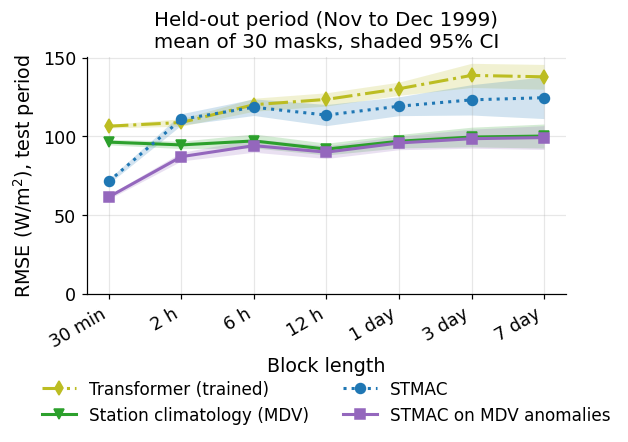

In [17]:
HO_PAIRS = [("transformer", "joint_r10"), ("transformer", "joint_rcv"), ("climatology", "joint_r10"),
            ("transformer", "anomaly"), ("climatology", "anomaly")]
T_ho = pd.concat([ru.paired_family(HO, a, b) for a, b in HO_PAIRS], ignore_index=True)
ru.atomic_csv(T_ho, RES / "E12_TF_heldout_tests.csv")
S_ho = []
for bl, g in HO.groupby("block_len", sort=True):
    r = {"block_len": bl, "label": LABEL[bl], "n": len(g)}
    for m in ["transformer", "joint_r10", "joint_rcv", "climatology", "anomaly"]:
        r[m], r[m + "_lo"], r[m + "_hi"] = ru.ci95(g["rmse_" + m])
    S_ho.append(r)
S_ho = pd.DataFrame(S_ho)
ru.atomic_csv(S_ho, RES / "E12_TF_heldout_summary.csv")
print(S_ho[["label", "n", "transformer", "climatology", "joint_r10", "joint_rcv", "anomaly"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print()
print(T_ho[["a", "b", "label", "mean_diff", "ci_lo", "ci_hi", "wins_b", "n", "p_holm"]]
      .to_string(index=False, float_format=lambda v: f"{v:9.3g}"))

x = np.arange(len(S_ho))
fig, ax = plt.subplots(figsize=(5.8, 4.6))
for col, name, c, ls, mk in [("transformer", "Transformer (trained)", "C8", "-.", "d"),
                             ("climatology", "Station climatology (MDV)", "C2", "-", "v"),
                             ("joint_r10", "STMAC", "C0", ":", "o"),
                             ("anomaly", "STMAC on MDV anomalies", "C4", "-", "s")]:
    ax.plot(x, S_ho[col], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
    ax.fill_between(x, S_ho[col + "_lo"], S_ho[col + "_hi"], color=c, alpha=0.2, lw=0)
ax.set_xticks(x)
ax.set_xticklabels(S_ho.label, rotation=30, ha="right")
ax.set_xlabel("Block length")
ax.set_ylabel(r"RMSE (W/m$^2$), test period")
ax.set_title(f"Held-out period (Nov to Dec 1999)\nmean of {N_SEEDS_HELDOUT} masks, shaded 95% CI")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(RES / "E12_TF_heldout.png")
plt.show()

In [18]:
print("INTERPRETASI PERIODE UJI")
print("=" * 88)
print(f"- Backend {TF_BACKEND}; {HO.seed.nunique()} realisasi per panjang blok; "
      f"periode uji mulai {IDX[TEST_START].date()}.")
NAMES = {"transformer": "Transformer", "climatology": "klimatologi", "joint_r10": "STMAC (r = 10)",
         "joint_rcv": f"STMAC (r = {idn(R_CV, 0)})",
         "anomaly": f"STMAC anomali (r = {idn(R_AN, 0)}, ridge = {idn(G_AN, 1)})"}
for a, b in HO_PAIRS:
    if b == "joint_rcv" and R_CV == RATIO:
        continue
    t = T_ho[(T_ho.a == a) & (T_ho.b == b)]
    wins = [r.label for r in t.itertuples() if r.mean_diff > 0 and r.p_holm < 0.05]
    loss = [r.label for r in t.itertuples() if r.mean_diff < 0 and r.p_holm < 0.05]
    ns = [r.label for r in t.itertuples() if r.p_holm >= 0.05]
    print(f"- {NAMES[b]} vs {NAMES[a]}: {NAMES[b]} lebih baik signifikan di "
          f"{', '.join(wins) if wins else 'tidak ada blok'}; {NAMES[a]} lebih baik signifikan di "
          f"{', '.join(loss) if loss else 'tidak ada blok'}; tidak berbeda di "
          f"{', '.join(ns) if ns else 'tidak ada blok'}.")
    print("  selisih rata-rata (positif = " + NAMES[b] + " lebih rendah): "
          + ", ".join(f"{r.label} {idn(r.mean_diff)}" for r in t.itertuples()) + " W/m2")

INTERPRETASI PERIODE UJI
- Backend PyTorch 2.9.1; 30 realisasi per panjang blok; periode uji mulai 1999-11-07.
- STMAC (r = 10) vs Transformer: STMAC (r = 10) lebih baik signifikan di 30 min, 12 h, 1 day, 3 day, 7 day; Transformer lebih baik signifikan di tidak ada blok; tidak berbeda di 2 h, 6 h.
  selisih rata-rata (positif = STMAC (r = 10) lebih rendah): 30 min 35,1, 2 h -2,0, 6 h 1,6, 12 h 10,0, 1 day 11,1, 3 day 15,5, 7 day 13,3 W/m2
- STMAC (r = 1.000) vs Transformer: STMAC (r = 1.000) lebih baik signifikan di 30 min, 12 h, 1 day, 3 day, 7 day; Transformer lebih baik signifikan di tidak ada blok; tidak berbeda di 2 h, 6 h.
  selisih rata-rata (positif = STMAC (r = 1.000) lebih rendah): 30 min 43,0, 2 h 4,3, 6 h 3,1, 12 h 11,4, 1 day 12,0, 3 day 17,4, 7 day 15,2 W/m2
- STMAC (r = 10) vs klimatologi: STMAC (r = 10) lebih baik signifikan di 30 min; klimatologi lebih baik signifikan di 2 h, 6 h, 12 h, 1 day, 3 day, 7 day; tidak berbeda di tidak ada blok.
  selisih rata-rata (positif 

## 6. Pembanding completion dan transfer peta restriksi (E9/E9B)

Low-rank completion dan GRMF tidak bergantung pada STMAC, jadi nilainya diambil dari `E9B_raw.csv`
(seed 0 sampai 9, termasuk versi dengan penyelarasan waktu surya). Kita menghitung ulang STMAC dengan
solver gabungan pada mask yang sama, lengkap dengan pembagian hari cerah dan berawan. Pembagian hari
memakai `sky_tools` bila tersedia; bila tidak, fungsi cadangan diperiksa terhadap jumlah sel cerah
dan berawan yang tersimpan.

In [19]:
if sk_proj is not None:
    OFF99, _ = sk_proj.detect_utc_offset(IDX, U_ALL, LON)
    _, CS99 = sk_proj.clear_sky_field(IDX, LAT, LON, OFF99)
    KT99 = sk_proj.daily_clear_sky_index(IDX, U_ALL, CS99, DAYTIME)
    CLEAR99, CLOUDY99 = sk_proj.sky_masks(KT99, KT_CLEAR, KT_CLOUDY)
    SKY_SRC = "sky_tools"
else:
    OFF99 = 3.0                                    # hasil deteksi offset di E9
    _, CS99 = ru.clear_sky_field(IDX, LAT, LON, OFF99)
    KT99 = ru.daily_clear_sky_index(IDX, U_ALL, CS99, DAYTIME)
    CLEAR99, CLOUDY99 = ru.sky_masks(KT99, KT_CLEAR, KT_CLOUDY)
    SKY_SRC = "stmac_rerun_utils (offset UTC+3)"
print(f"Sumber pembagian hari: {SKY_SRC} | sel siang cerah {np.mean(CLEAR99[:, DAYTIME]) * 100:.1f}% | "
      f"berawan {np.mean(CLOUDY99[:, DAYTIME]) * 100:.1f}%")

E9B = load_csv("E9B_raw.csv")
OUT9 = RES / "E12_E9J_raw.csv"
rows = pd.read_csv(OUT9).to_dict("records") if OUT9.exists() else []
done = {(int(r["seed"]), int(r["block_len"])) for r in rows}
n_match = 0
for seed in range(N_SEEDS_E9):
    for bl, lab in BLOCKS:
        mask, _ = sj.build_block_mask(N, T, bl, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        evc, evk = ev & CLEAR99, ev & CLOUDY99
        if E9B is not None:
            ref = E9B[(E9B.seed == seed) & (E9B.block_len == bl)].iloc[0]
            n_match += (int(ev.sum()), int(evc.sum()), int(evk.sum())) == \
                       (int(ref.n_eval), int(ref.n_clear), int(ref.n_cloudy))
        if (seed, bl) in done:
            continue
        rec = {"seed": seed, "block_len": bl, "block_label": lab}
        C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
        recon = {"joint_trivial": sj.stmac_joint(U_ALL, mask, L_G, L_TIME, None, None, ALPHA_T, ALPHA_S),
                 "joint_longitude": sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, ALPHA_T, ALPHA_S),
                 "climatology": np.where(mask, U_ALL, C),
                 "anomaly": sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, R_AN, 1.0,
                                           ridge=G_AN, prior=C)}
        for name, U_r in recon.items():
            rec["rmse_" + name] = sj.rmse(U_ALL, U_r, ev)
            rec["clear_" + name] = sj.rmse(U_ALL, U_r, evc)
            rec["cloudy_" + name] = sj.rmse(U_ALL, U_r, evk)
        rows.append(rec)
        ru.atomic_csv(pd.DataFrame(rows), OUT9)
E9J = pd.DataFrame(rows).sort_values(["block_len", "seed"]).reset_index(drop=True)
if E9B is not None:
    print(f"Jumlah sel (siang, cerah, berawan) cocok dengan E9B_raw pada {n_match} dari "
          f"{N_SEEDS_E9 * len(BLOCKS)} baris")
    keep = ["seed", "block_len"] + [c for c in E9B.columns
                                     if c.split("_", 1)[0] in ("rmse", "clear", "cloudy")
                                     and ("lowrank" in c or "grmf" in c or "stmac" in c)]
    base = E9B[keep].rename(columns=lambda c: c.replace("stmac_", "legacy_"))
    E9J = E9J.merge(base, on=["seed", "block_len"], how="left")
E9_OLD = load_csv("E9_raw.csv")
if E9_OLD is not None:
    extra = [c for c in E9_OLD.columns if c.startswith(("rmse_grmf_cv", "cloudy_grmf_cv", "clear_grmf_cv"))]
    E9J = E9J.merge(E9_OLD[["seed", "block_len"] + extra], on=["seed", "block_len"], how="left")
print(f"{len(E9J)} baris, kolom pembanding: "
      f"{[c for c in E9J.columns if c.startswith('rmse_') and 'joint' not in c]}")

Sumber pembagian hari: sky_tools | sel siang cerah 74.5% | berawan 11.5%
Jumlah sel (siang, cerah, berawan) cocok dengan E9B_raw pada 70 dari 70 baris
70 baris, kolom pembanding: ['rmse_climatology', 'rmse_anomaly', 'rmse_legacy_trivial', 'rmse_legacy_longitude', 'rmse_lowrank_raw', 'rmse_lowrank_aligned', 'rmse_grmf_raw', 'rmse_grmf_aligned', 'rmse_grmf_cv']


In [20]:
fam9 = []
for subset, pre in [("all", "rmse_"), ("clear", "clear_"), ("cloudy", "cloudy_")]:
    for a in ["lowrank_raw", "grmf_raw", "lowrank_aligned", "grmf_aligned", "legacy_longitude"]:
        if pre + a in E9J:
            t = ru.paired_family(E9J, a, "joint_longitude", prefix=pre)
            t["subset"] = subset
            fam9.append(t)
    if pre + "grmf_cv" in E9J:
        t = ru.paired_family(E9J, "grmf_cv", "joint_longitude", prefix=pre); t["subset"] = subset
        fam9.append(t)
    t = ru.paired_family(E9J, "joint_trivial", "joint_longitude", prefix=pre); t["subset"] = subset
    fam9.append(t)
    for a, b in [("climatology", "joint_longitude"), ("climatology", "anomaly"), ("lowrank_raw", "anomaly")]:
        if pre + a in E9J:
            t = ru.paired_family(E9J, a, b, prefix=pre); t["subset"] = subset
            fam9.append(t)
T9 = pd.concat(fam9, ignore_index=True)
ru.atomic_csv(T9, RES / "E12_E9J_tests.csv")

S9 = {}
for subset, pre in [("all", "rmse_"), ("clear", "clear_"), ("cloudy", "cloudy_")]:
    cols = [c for c in E9J.columns if c.startswith(pre)]
    S9[subset] = E9J.groupby("block_len")[cols].mean().rename(index=LABEL)
    S9[subset].columns = [c[len(pre):] for c in cols]
    ru.atomic_csv(S9[subset].reset_index().rename(columns={"block_len": "label"}),
                  RES / f"E12_E9J_summary_{subset}.csv")
for subset in S9:
    print(f"\n{subset.upper()} (W/m2, rata-rata {N_SEEDS_E9} realisasi)")
    print(S9[subset].to_string(float_format=lambda v: f"{v:8.1f}"))

# uji gabungan 70 pasangan untuk penyelarasan di dalam solver gabungan
d_all = (E9J.rmse_joint_trivial - E9J.rmse_joint_longitude).to_numpy()
p_pool = stats.wilcoxon(E9J.rmse_joint_trivial, E9J.rmse_joint_longitude).pvalue
POOL = {"mean_gain": float(d_all.mean()), "ci": ru.ci95(d_all)[1:], "wins": int((d_all > 0).sum()),
        "n": len(d_all), "p": float(p_pool)}
AL_OLD = load_csv("E9B_alignment_tests.csv")

# sensitivitas rank: STMAC gabungan pada mask yang sama dengan E9_rank_sensitivity
RK = load_csv("E9_rank_sensitivity.csv")
if RK is not None:
    rk_rows = []
    for (seed, bl), g in RK.groupby(["seed", "block_len"]):
        mask, _ = sj.build_block_mask(N, T, int(bl), 0.10, seed=int(seed))
        ev = (~mask) & DAYTIME[None, :]
        rk_rows.append({"seed": seed, "block_len": bl,
                        "rmse_joint": sj.rmse(U_ALL, sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA,
                                                                    None, ALPHA_T, ALPHA_S), ev),
                        "rmse_legacy": g.rmse_stmac.iloc[0]})
    RKJ = pd.DataFrame(rk_rows)
    rk_tab = RK.groupby(["block_len", "rank"]).rmse_softimpute.mean().unstack()
    RK_SUM = pd.DataFrame({
        "lowrank_rank1": rk_tab[1], "lowrank_rank2": rk_tab[2],
        "lowrank_min": rk_tab.min(axis=1), "lowrank_max": rk_tab.max(axis=1),
        "joint": RKJ.groupby("block_len").rmse_joint.mean(),
        "legacy": RKJ.groupby("block_len").rmse_legacy.mean()}).rename(index=LABEL)
    ru.atomic_csv(RK_SUM.reset_index().rename(columns={"block_len": "label"}),
                  RES / "E12_E9J_rank_sensitivity.csv")
    print("\nSensitivitas rank low-rank (3 seed) dan STMAC pada mask yang sama")
    print(RK_SUM.to_string(float_format=lambda v: f"{v:8.1f}"))


ALL (W/m2, rata-rata 10 realisasi)
           joint_trivial  joint_longitude  climatology  anomaly  legacy_trivial  legacy_longitude  lowrank_raw  lowrank_aligned  grmf_raw  grmf_aligned  grmf_cv
block_len                                                                                                                                                       
30 min             114.4            114.3        161.8     89.4           197.3             196.0        191.5            188.9     189.7         187.2    198.0
2 h                183.3            183.1        163.0    140.8           197.4             196.7        191.5            189.7     190.9         189.1    314.2
6 h                189.6            189.2        159.9    151.5           193.2             192.3        189.8            187.6     189.4         187.3    370.1
12 h               195.1            195.1        161.6    156.8           195.5             195.1        190.8            189.2     190.4         188.8    477.

In [21]:
def sig_summary(a, subset, b="joint_longitude", nama_b="STMAC"):
    t = T9[(T9.a == a) & (T9.b == b) & (T9.subset == subset)]
    lead = t[t.mean_diff > 0]; trail = t[t.mean_diff < 0]
    return (f"{nama_b} unggul di {len(lead)}/{len(t)} blok ({int((lead.p_holm < 0.05).sum())} signifikan), "
            f"tertinggal di {len(trail)}/{len(t)} ({int((trail.p_holm < 0.05).sum())} signifikan)")


print("INTERPRETASI E9/E9B DENGAN SOLVER GABUNGAN")
print("=" * 88)
for subset, nama in [("all", "semua sel siang"), ("clear", "hari cerah"), ("cloudy", "hari berawan")]:
    s = S9[subset]
    print(f"- {nama}: rata-rata lintas blok STMAC {idn(s.joint_longitude.mean())} W/m2, "
          f"low-rank {idn(s.lowrank_raw.mean())}, GRMF {idn(s.grmf_raw.mean())} W/m2.")
    print(f"  Terhadap low-rank: {sig_summary('lowrank_raw', subset)}.")
    print(f"  Terhadap GRMF: {sig_summary('grmf_raw', subset)}.")
    print(f"  Klimatologi {idn(s.climatology.mean())} W/m2; STMAC terhadap klimatologi: "
          f"{sig_summary('climatology', subset)}.")
    print(f"  Varian anomali {idn(s.anomaly.mean())} W/m2; terhadap klimatologi: "
          f"{sig_summary('climatology', subset, 'anomaly', 'varian anomali')}; terhadap low-rank: "
          f"{sig_summary('lowrank_raw', subset, 'anomaly', 'varian anomali')}.")
if "rmse_grmf_cv" in E9J:
    print(f"- Terhadap GRMF hasil validasi silang (rank 4): {sig_summary('grmf_cv', 'all')}.")
lo_, hi_ = POOL["ci"]
print(f"- Penyelarasan waktu surya di dalam solver gabungan: rata-rata {idn(POOL['mean_gain'], 2)} W/m2 "
      f"(CI {idn(lo_, 2)} sampai {idn(hi_, 2)}), menang {POOL['wins']}/{POOL['n']}, p = {POOL['p']:.1e}.")
if AL_OLD is not None:
    al = AL_OLD[AL_OLD.subset == "all"].groupby("contrast").gain.mean()
    print(f"  Sebagai pembanding (E9B): low-rank {idn(al.get('lowrank', np.nan), 2)} W/m2, "
          f"GRMF {idn(al.get('grmf', np.nan), 2)} W/m2, solver lama {idn(al.get('stmac', np.nan), 2)} W/m2.")
tc = T9[(T9.a == "joint_trivial") & (T9.subset == "cloudy")]
print(f"- Pada hari berawan, keuntungan penyelarasan di solver gabungan berkisar {idn(tc.mean_diff.min(), 2)} "
      f"sampai {idn(tc.mean_diff.max(), 2)} W/m2, signifikan di {int((tc.p_holm < 0.05).sum())} blok.")
if RK is not None:
    for lab_, r in RK_SUM.iterrows():
        print(f"- Blok {lab_}: low-rank rank 1 {idn(r.lowrank_rank1)}, rank 2 {idn(r.lowrank_rank2)}, "
              f"rentang rank {idn(r.lowrank_min)} sampai {idn(r.lowrank_max)} W/m2; STMAC gabungan "
              f"{idn(r.joint)} W/m2 (solver lama {idn(r.legacy)}).")

INTERPRETASI E9/E9B DENGAN SOLVER GABUNGAN
- semua sel siang: rata-rata lintas blok STMAC 182,0 W/m2, low-rank 191,0, GRMF 190,4 W/m2.
  Terhadap low-rank: STMAC unggul di 3/7 blok (2 signifikan), tertinggal di 4/7 (2 signifikan).
  Terhadap GRMF: STMAC unggul di 3/7 blok (2 signifikan), tertinggal di 4/7 (2 signifikan).
  Klimatologi 162,6 W/m2; STMAC terhadap klimatologi: STMAC unggul di 1/7 blok (1 signifikan), tertinggal di 6/7 (6 signifikan).
  Varian anomali 145,9 W/m2; terhadap klimatologi: varian anomali unggul di 7/7 blok (7 signifikan), tertinggal di 0/7 (0 signifikan); terhadap low-rank: varian anomali unggul di 7/7 blok (7 signifikan), tertinggal di 0/7 (0 signifikan).
- hari cerah: rata-rata lintas blok STMAC 154,5 W/m2, low-rank 159,9, GRMF 158,7 W/m2.
  Terhadap low-rank: STMAC unggul di 2/7 blok (2 signifikan), tertinggal di 5/7 (2 signifikan).
  Terhadap GRMF: STMAC unggul di 2/7 blok (1 signifikan), tertinggal di 5/7 (2 signifikan).
  Klimatologi 130,6 W/m2; STMAC ter

## 7. Model ekonomi dengan angka baru

Bagian ini memperbarui Tabel II dari rata-rata 20 realisasi pada blok 3 hari, lalu mengulang koreksi
E10 (MAE dan lima struktur settlement) memakai residual solver gabungan. Residual pure temporal
diambil dari `E10_residuals_3day.npz` karena mask-nya sama (seed 0 sampai 4).

RMSE pure temporal pada blok panjang melampaui irradiansi fisik, jadi kita menambahkan dua baseline
naif yang dibatasi secara fisik: pure temporal yang dipotong ke rentang 0 sampai 1400 W/m², dan
profil diurnal klimatologis per stasiun (rata-rata nilai teramati pada jam yang sama dalam jendela
±15 hari). Keduanya hanya memakai sel teramati.

In [22]:
EPS, H_D = 0.10, 4380.0
SCEN = [("Conservative", 40.0, 3.0), ("Mordor 2031", 52.7, 5.0), ("Stricter", 52.7, 10.0)]


def annual_cost(P_gw, R, c):
    # Persamaan (5), juta USD per tahun
    return P_gw * 1e3 * (R / 1000.0) * EPS * H_D * c / 1e6


s3 = S7.set_index("block_len").loc[864]
R3 = {"pure_temporal": s3.pure_temporal, "pt_clipped": s3.pt_clipped, "climatology": s3.climatology,
      "transformer": s3.transformer, "joint_longitude": s3.joint_longitude,
      "legacy_longitude": s3.legacy_longitude,
      "anomaly": float(S_an.set_index("block_len").loc[864].anomaly)}
tab2 = []
for method in ["joint_longitude", "anomaly"]:
    for nm, P, c in SCEN:
        pt, tf, cl, st = (annual_cost(P, R3[k], c)
                          for k in ("pure_temporal", "transformer", "climatology", method))
        tab2.append({"method": method, "scenario": nm, "GW": P, "usd_per_mwh": c, "PT": pt, "TF": tf,
                     "MDV": cl, "STMAC": st, "savings_vs_PT": pt - st, "savings_vs_TF": tf - st,
                     "savings_vs_MDV": cl - st})
TAB2 = pd.DataFrame(tab2)
ru.atomic_csv(TAB2, RES / "E12_table2.csv")
print("RMSE blok 3 hari (W/m2):", {k: round(v, 1) for k, v in R3.items()})
print(TAB2.to_string(index=False, float_format=lambda v: f"{v:8.1f}"))

# residual pada lima mask E10
BLOCK_E10, SEEDS_E10 = 864, range(5)
NPZ = RES / "E10_residuals_3day.npz"
res_pt, res_j, res_clip, res_clim, res_an = [], [], [], [], []


for seed in SEEDS_E10:
    mask, _ = sj.build_block_mask(N, T, BLOCK_E10, EPS, seed=seed)
    ev = (~mask) & DAYTIME[None, :]
    U_pt = sj.pure_temporal(U_ALL, mask, L_TIME, 10.0)
    U_j = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, ALPHA_T, ALPHA_S)
    C = ru.mdv_field(U_ALL, mask, IDX, MDV_HW)
    U_an = sj.stmac_joint(U_ALL, mask, L_G, L_TIME, DELTA, None, R_AN, 1.0, ridge=G_AN, prior=C)
    res_pt.append(U_ALL[ev] - U_pt[ev])
    res_j.append(U_ALL[ev] - U_j[ev])
    res_clip.append(U_ALL[ev] - np.clip(U_pt, 0.0, PT_CLIP)[ev])
    res_clim.append(U_ALL[ev] - np.where(mask, U_ALL, C)[ev])
    res_an.append(U_ALL[ev] - U_an[ev])
RESID = {"pure_temporal": np.concatenate(res_pt), "joint_longitude": np.concatenate(res_j),
         "anomaly": np.concatenate(res_an), "pt_clipped": np.concatenate(res_clip),
         "climatology": np.concatenate(res_clim)}
if NPZ.exists():
    z = np.load(NPZ)
    if len(z["pure_temporal"]) == len(RESID["pure_temporal"]):
        dmax = float(np.abs(z["pure_temporal"] - RESID["pure_temporal"]).max())
        print(f"\nResidual pure temporal vs E10_residuals_3day.npz: {len(z['pure_temporal']):,} sel, "
              f"selisih maksimum {dmax:.1e} W/m2 (perbedaan numerik solver sparse)")
    else:
        print("\nPanjang residual berbeda dengan E10_residuals_3day.npz; mask tidak sama.")
    RESID["legacy_longitude"] = z["stmac_longitude"]
np.savez_compressed(RES / "E12_residuals_3day.npz", **RESID)
for k, e in RESID.items():
    print(f"{k:18s} n={len(e):8,d} | RMSE {np.sqrt(np.mean(e ** 2)):8.1f} | MAE {np.mean(np.abs(e)):8.1f}")

RMSE blok 3 hari (W/m2): {'pure_temporal': np.float64(1904.4), 'pt_clipped': np.float64(657.6), 'climatology': np.float64(166.2), 'transformer': np.float64(250.7), 'joint_longitude': np.float64(202.3), 'legacy_longitude': np.float64(199.7), 'anomaly': 163.3}
         method     scenario       GW  usd_per_mwh       PT       TF      MDV    STMAC  savings_vs_PT  savings_vs_TF  savings_vs_MDV
joint_longitude Conservative     40.0          3.0    100.1     13.2      8.7     10.6           89.5            2.5            -1.9
joint_longitude  Mordor 2031     52.7          5.0    219.8     28.9     19.2     23.3          196.5            5.6            -4.2
joint_longitude     Stricter     52.7         10.0    439.6     57.9     38.4     46.7          392.9           11.2            -8.3
        anomaly Conservative     40.0          3.0    100.1     13.2      8.7      8.6           91.5            4.6             0.2
        anomaly  Mordor 2031     52.7          5.0    219.8     28.9     19.

In [23]:
RATED = 1000.0


def agg_rmse(e): return float(np.sqrt(np.mean(e ** 2)))
def agg_mae(e): return float(np.mean(np.abs(e)))
def agg_deadband(e, d): return float(np.mean(np.maximum(np.abs(e) - d * RATED, 0.0)))


def agg_tiered(e, d1=0.05, d2=0.15, m1=1.0, m2=1.5):
    a = np.abs(e) / RATED
    w = np.where(a <= d1, 0.0, np.where(a <= d2, m1 * (a - d1), m1 * (d2 - d1) + m2 * (a - d2)))
    return float(np.mean(w) * RATED)


def agg_asym(e, up=1.5, dn=0.5): return float(np.mean(np.where(e > 0, up, dn) * np.abs(e)))


MODELS_E10 = [("A", "linear RMSE (Eq. 5)", agg_rmse), ("B", "linear MAE", agg_mae),
              ("C", "deadband 5%", lambda e: agg_deadband(e, 0.05)),
              ("D", "deadband 10%", lambda e: agg_deadband(e, 0.10)),
              ("E", "tiered 5/15%, 1.0x/1.5x", agg_tiered),
              ("F", "asymmetric 1.5x/0.5x", agg_asym)]
BASELINES = [("pure_temporal", "pure temporal"), ("pt_clipped", "PT dipotong 0-1400"),
             ("climatology", "klimatologi +-15 hari")]
rows = []
for method in ["joint_longitude", "anomaly"]:
    for base_key, base_name in BASELINES:
        for tag, name, f in MODELS_E10:
            gb, gs = f(RESID[base_key]), f(RESID[method])
            r = {"method": method, "baseline": base_name, "model": tag, "name": name,
                 "g_base": gb, "g_stmac": gs}
            for nm, P, c in SCEN:
                r["savings_" + nm] = annual_cost(P, gb, c) - annual_cost(P, gs, c)
            rows.append(r)
ECON = pd.DataFrame(rows)
for (method, base_name), grp in ECON.groupby(["method", "baseline"]):
    ref = grp[grp.model == "A"].iloc[0]
    for nm, _, _ in SCEN:
        ECON.loc[grp.index, "dev_" + nm] = (grp["savings_" + nm] / ref["savings_" + nm] - 1) * 100
ru.atomic_csv(ECON, RES / "E12_econ_structures.csv")

sweep = []
base_ref = ECON[(ECON.method == "joint_longitude") & (ECON.baseline == "pure temporal")
                & (ECON.model == "A")].iloc[0]["savings_Conservative"]
for d in [0.0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20]:
    s = annual_cost(40, agg_deadband(RESID["pure_temporal"], d), 3) - \
        annual_cost(40, agg_deadband(RESID["joint_longitude"], d), 3)
    sweep.append({"kind": "deadband", "param": d, "savings": s, "dev_pct": (s / base_ref - 1) * 100})
for m2 in [1.0, 1.25, 1.5, 2.0, 3.0, 4.0]:
    s = annual_cost(40, agg_tiered(RESID["pure_temporal"], m2=m2), 3) - \
        annual_cost(40, agg_tiered(RESID["joint_longitude"], m2=m2), 3)
    sweep.append({"kind": "upper tier rate", "param": m2, "savings": s, "dev_pct": (s / base_ref - 1) * 100})
SWP = pd.DataFrame(sweep)
ru.atomic_csv(SWP, RES / "E12_econ_structure_sweep.csv")

pd.set_option("display.width", 200)
print(ECON[["method", "baseline", "model", "g_base", "g_stmac", "savings_Conservative",
            "savings_Mordor 2031", "savings_Stricter", "dev_Conservative"]]
      .to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print()
print(SWP.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

         method              baseline model   g_base  g_stmac  savings_Conservative  savings_Mordor 2031  savings_Stricter  dev_Conservative
joint_longitude         pure temporal     A   1812.8    201.0                  84.7                186.0             372.0               0.0
joint_longitude         pure temporal     B   1127.8    127.2                  52.6                115.5             230.9             -37.9
joint_longitude         pure temporal     C   1079.0     88.3                  52.1                114.3             228.7             -38.5
joint_longitude         pure temporal     D   1032.0     64.7                  50.8                111.6             223.3             -40.0
joint_longitude         pure temporal     E   1572.2    112.6                  76.7                168.5             336.9              -9.4
joint_longitude         pure temporal     F   1280.4    128.3                  60.6                133.0             265.9             -28.5
joint_longitu

In [24]:
print("INTERPRETASI MODEL EKONOMI")
print("=" * 88)
MNAME = {"joint_longitude": "STMAC", "anomaly": "STMAC anomali"}
for r in TAB2.itertuples():
    print(f"- {MNAME[r.method]}, {r.scenario} ({idn(r.GW)} GW, {idn(r.usd_per_mwh, 0)} USD/MWh): "
          f"PT {idn(r.PT)}, Transformer {idn(r.TF)}, MDV {idn(r.MDV)}, STMAC {idn(r.STMAC)} juta USD/tahun; "
          f"hemat vs PT {idn(r.savings_vs_PT)}, vs Transformer {idn(r.savings_vs_TF)}, "
          f"vs MDV {idn(r.savings_vs_MDV)}.")
pt_rows = ECON[(ECON.method == "joint_longitude") & (ECON.baseline == "pure temporal")]
alt = pt_rows[pt_rows.model != "A"]
print(f"- Koreksi struktur settlement (STMAC vs PT): MAE {idn(alt[alt.model == 'B'].dev_Conservative.iloc[0], 0)}%, "
      f"lima struktur {idn(alt.dev_Conservative.min(), 0)}% sampai {idn(alt.dev_Conservative.max(), 0)}%.")
plaus = SWP[(SWP.kind != "upper tier rate") | (SWP.param <= 2.0)]
print(f"- Sweep deadband dan tarif tier sampai 2x memberi {idn(plaus.savings.min())} sampai "
      f"{idn(plaus.savings.max())} juta USD/tahun (deviasi {idn(plaus.dev_pct.min(), 0)}% sampai "
      f"{idn(plaus.dev_pct.max(), 0)}%). "
      + ("Ada nilai di atas Persamaan (5), jadi Persamaan (5) bukan batas atas."
         if plaus.dev_pct.max() > 0 else "Semua nilai di bawah Persamaan (5)."))
for method in ["joint_longitude", "anomaly"]:
    for base_key, base_name in BASELINES:
        rr = ECON[(ECON.method == method) & (ECON.baseline == base_name) & (ECON.model == "A")].iloc[0]
        print(f"- {MNAME[method]} vs {base_name}: RMSE {idn(rr.g_stmac)} lawan {idn(rr.g_base)} W/m2; "
              f"selisih biaya menurut Persamaan (5) {idn(rr['savings_Conservative'])} sampai "
              f"{idn(rr['savings_Stricter'])} juta USD/tahun (negatif berarti baseline lebih murah).")

INTERPRETASI MODEL EKONOMI
- STMAC, Conservative (40,0 GW, 3 USD/MWh): PT 100,1, Transformer 13,2, MDV 8,7, STMAC 10,6 juta USD/tahun; hemat vs PT 89,5, vs Transformer 2,5, vs MDV -1,9.
- STMAC, Mordor 2031 (52,7 GW, 5 USD/MWh): PT 219,8, Transformer 28,9, MDV 19,2, STMAC 23,3 juta USD/tahun; hemat vs PT 196,5, vs Transformer 5,6, vs MDV -4,2.
- STMAC, Stricter (52,7 GW, 10 USD/MWh): PT 439,6, Transformer 57,9, MDV 38,4, STMAC 46,7 juta USD/tahun; hemat vs PT 392,9, vs Transformer 11,2, vs MDV -8,3.
- STMAC anomali, Conservative (40,0 GW, 3 USD/MWh): PT 100,1, Transformer 13,2, MDV 8,7, STMAC 8,6 juta USD/tahun; hemat vs PT 91,5, vs Transformer 4,6, vs MDV 0,2.
- STMAC anomali, Mordor 2031 (52,7 GW, 5 USD/MWh): PT 219,8, Transformer 28,9, MDV 19,2, STMAC 18,8 juta USD/tahun; hemat vs PT 201,0, vs Transformer 10,1, vs MDV 0,3.
- STMAC anomali, Stricter (52,7 GW, 10 USD/MWh): PT 439,6, Transformer 57,9, MDV 38,4, STMAC 37,7 juta USD/tahun; hemat vs PT 401,9, vs Transformer 20,2, vs MDV 0

## 8. Jaringan satelit 2019 (E11)

Data NSRDB Meteosat Prime Meridian 2019 (30 menit) dibaca dari cache `data/modern/`. Urutan titik
dibangun ulang dengan aturan penempatan E11 (11 titik NLR, lalu titik acak di daratan Saudi dengan
jarak minimum 110 km, seed 7) dan dicocokkan dengan nama berkas cache. Pure temporal dan low-rank
diambil dari `E11_raw.csv`. Klimatologi stasiun dan varian anomali ikut dihitung; pasangan
$(r,\gamma)$ varian anomali memakai hasil pemilihan pada data 1999 tanpa penyetelan ulang. Karena
gate koherensi spasial E11 gagal, bagian ini hanya menjadi pemeriksaan struktural, dan angka
akurasinya tidak dibaca sebagai bukti jaringan modern.

In [25]:
SIGMA_KM, KNN_K, MIN_SEP_KM, N_LIST = 300.0, 3, 110.0, [11, 25, 50]
MOD = DATA / "modern"
lat50, lon50 = ru.place_stations(LAT, LON, max(N_LIST), seed=7, min_sep_km=MIN_SEP_KM)
files = [MOD / f"msg_prime_2019_{a:.3f}_{b:.3f}.csv" for a, b in zip(lat50, lon50)]
missing = [f.name for f in files if not f.exists()]
assert not missing, f"berkas cache tidak ditemukan: {missing[:3]}"

frames = [pd.read_csv(f, parse_dates=["time"]) for f in files]
common = None
for d in frames:
    s_ = d.set_index("time")["ghi"]; s_ = s_[~s_.index.duplicated()]
    common = s_.index if common is None else common.intersection(s_.index)
MM = np.vstack([d.set_index("time")["ghi"].reindex(common).to_numpy(float) for d in frames])
MM[MM <= -900] = np.nan
MM = np.clip(MM, 0.0, 1500.0)
good_t = ~np.isnan(MM).any(axis=0)
U_SAT = MM[:, good_t]
IDX_SAT = pd.DatetimeIndex(common[good_t])
DT_SAT = int(round(np.median(np.diff(IDX_SAT.values)).astype("timedelta64[m]").astype(int)))
T_SAT = U_SAT.shape[1]
BLOCKS_SAT = []
for h in [0.5, 2, 6, 12, 24, 72, 168]:
    n_ = max(1, int(round(h * 60 / DT_SAT)))
    lab_ = f"{n_ * DT_SAT} min" if n_ * DT_SAT < 60 else (
        f"{n_ * DT_SAT // 60} h" if n_ * DT_SAT < 1440 else f"{n_ * DT_SAT // 1440} day")
    BLOCKS_SAT.append((n_, lab_))
LABEL_SAT = dict(BLOCKS_SAT)

idx_naive = IDX_SAT.tz_convert(None) if IDX_SAT.tz is not None else IDX_SAT
if sk_proj is not None:
    OFF_SAT, _ = sk_proj.detect_utc_offset(IDX_SAT, U_SAT, lon50)
    COSZ_SAT, CS_SAT = sk_proj.clear_sky_field(IDX_SAT, lat50, lon50, OFF_SAT)
    DAY_SAT = COSZ_SAT.max(axis=0) > 0.15
    KT_SAT = sk_proj.daily_clear_sky_index(IDX_SAT, U_SAT, CS_SAT, DAY_SAT)
else:
    OFF_SAT = 0.0
    COSZ_SAT, CS_SAT = ru.clear_sky_field(idx_naive, lat50, lon50, OFF_SAT)
    DAY_SAT = COSZ_SAT.max(axis=0) > 0.15
    KT_SAT = ru.daily_clear_sky_index(idx_naive, U_SAT, CS_SAT, DAY_SAT)
build_graph = ss_proj.build_graph if (ss_proj is not None and hasattr(ss_proj, "build_graph")) else ru.build_graph
L_TIME_SAT = sj.build_temporal_smoothness(T_SAT)
NETS = {}
for n in N_LIST:
    _, Ln, _ = build_graph(lat50[:n], lon50[:n], SIGMA_KM, KNN_K)
    NETS[n] = dict(U=U_SAT[:n], L=Ln, delta=(lon50[:n] - lon50[:n].mean()) / 15 * 60 / DT_SAT,
                   day=COSZ_SAT[:n].max(axis=0) > 0.15, cloudy=KT_SAT[:n] < KT_CLOUDY)
print(f"{U_SAT.shape[0]} titik x {T_SAT:,} timestamp, resolusi {DT_SAT} menit, puncak {U_SAT.max():.0f} W/m2")
print("Blok:", BLOCKS_SAT)

E11_OLD = load_csv("E11_raw.csv")
if E11_OLD is not None:
    ok = 0
    for r in E11_OLD.itertuples():
        net = NETS[int(r.N)]
        mask, _ = sj.build_block_mask(int(r.N), T_SAT, int(r.block_len), 0.10, seed=int(r.seed))
        ev = (~mask) & net["day"][None, :]
        ok += (int(ev.sum()), int((ev & net["cloudy"]).sum())) == (int(r.n_eval), int(r.n_cloudy))
    print(f"Jumlah sel evaluasi dan sel berawan cocok dengan E11_raw pada {ok} dari {len(E11_OLD)} baris")
    r0 = E11_OLD[(E11_OLD.N == 11) & (E11_OLD.seed == 0)].iloc[0]
    net = NETS[11]
    mask, _ = sj.build_block_mask(11, T_SAT, int(r0.block_len), 0.10, seed=0)
    ev = (~mask) & net["day"][None, :]
    v_leg = sj.rmse(net["U"], sj.stmac_legacy(np.where(mask, net["U"], 0.0), mask, net["L"],
                                              L_TIME_SAT, net["delta"], 4, 10.0, 1.0), ev)
    print(f"Solver lama N=11, seed 0, {r0.block_label}: {v_leg:.6f} vs tersimpan {r0.rmse_stmac_longitude:.6f}")

50 titik x 17,520 timestamp, resolusi 30 menit, puncak 1147 W/m2
Blok: [(1, '30 min'), (4, '2 h'), (12, '6 h'), (24, '12 h'), (48, '1 day'), (144, '3 day'), (336, '7 day')]
Jumlah sel evaluasi dan sel berawan cocok dengan E11_raw pada 210 dari 210 baris
Solver lama N=11, seed 0, 30 min: 90.897878 vs tersimpan 90.897878


In [26]:
OUT11 = RES / "E12_E11J_raw.csv"
rows = pd.read_csv(OUT11).to_dict("records") if OUT11.exists() else []
done = {(int(r["N"]), int(r["seed"]), int(r["block_len"])) for r in rows}
t_start = time.time()
for n in N_LIST:
    net = NETS[n]
    for seed in range(N_SEEDS_E9):
        for bl, lab in BLOCKS_SAT:
            if (n, seed, bl) in done:
                continue
            mask, _ = sj.build_block_mask(n, T_SAT, bl, 0.10, seed=seed)
            ev = (~mask) & net["day"][None, :]
            rec = {"N": n, "seed": seed, "block_len": bl, "block_label": lab}
            Y = np.where(mask, net["U"], 0.0)
            C = ru.mdv_field(Y, mask, IDX_SAT, MDV_HW, dt_min=DT_SAT)
            recon = {"joint_trivial": sj.stmac_joint(Y, mask, net["L"], L_TIME_SAT, None, None,
                                                     ALPHA_T, ALPHA_S),
                     "joint_longitude": sj.stmac_joint(Y, mask, net["L"], L_TIME_SAT, net["delta"], None,
                                                       ALPHA_T, ALPHA_S),
                     "climatology": np.where(mask, net["U"], C),
                     "anomaly": sj.stmac_joint(Y, mask, net["L"], L_TIME_SAT, net["delta"], None,
                                               R_AN, 1.0, ridge=G_AN, prior=C)}
            for name, U_r in recon.items():
                rec["rmse_" + name] = sj.rmse(net["U"], U_r, ev)
                rec["cloudy_" + name] = sj.rmse(net["U"], U_r, ev & net["cloudy"])
            rows.append(rec)
        ru.atomic_csv(pd.DataFrame(rows), OUT11)
    print(f"N={n} selesai | {(time.time() - t_start) / 60:.1f} menit", flush=True)
E11J = pd.DataFrame(rows)
if E11_OLD is not None:
    keep = ["N", "seed", "block_len", "rmse_pure_temporal", "cloudy_pure_temporal",
            "rmse_softimpute_cv", "cloudy_softimpute_cv", "rmse_stmac_longitude", "cloudy_stmac_longitude"]
    E11J = E11J.merge(E11_OLD[keep].rename(columns={"rmse_stmac_longitude": "rmse_legacy_longitude",
                                                    "cloudy_stmac_longitude": "cloudy_legacy_longitude"}),
                      on=["N", "seed", "block_len"], how="left")

# rasio pada blok tengah, seed 0, seperti bagian 9 notebook E11
RAT_GRID_SAT = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0]
mid_bl, mid_lab = BLOCKS_SAT[len(BLOCKS_SAT) // 2]
rat_rows = []
for n in N_LIST:
    net = NETS[n]
    mask, _ = sj.build_block_mask(n, T_SAT, mid_bl, 0.10, seed=0)
    ev = (~mask) & net["day"][None, :]
    for r in RAT_GRID_SAT:
        U_r = sj.stmac_joint(np.where(mask, net["U"], 0.0), mask, net["L"], L_TIME_SAT, net["delta"],
                             None, r, 1.0)
        rat_rows.append({"N": n, "ratio": r, "rmse": sj.rmse(net["U"], U_r, ev)})
RAT11 = pd.DataFrame(rat_rows)
ru.atomic_csv(RAT11, RES / "E12_E11J_ratio.csv")

M11 = ["pure_temporal", "softimpute_cv", "climatology", "legacy_longitude", "joint_trivial",
       "joint_longitude", "anomaly"]
M11 = [m for m in M11 if "rmse_" + m in E11J]
S11 = E11J.groupby(["N", "block_len"])[[f"rmse_{m}" for m in M11]].mean().reset_index()
S11["label"] = S11.block_len.map(LABEL_SAT)
ru.atomic_csv(S11, RES / "E12_E11J_summary.csv")
grow11 = []
for n in N_LIST:
    pv = E11J[E11J.N == n].pivot(index="seed", columns="block_len")
    for m in M11:
        g_ = (pv[("rmse_" + m, BLOCKS_SAT[-1][0])] / pv[("rmse_" + m, BLOCKS_SAT[0][0])]).to_numpy()
        mu, lo, hi = ru.ci95(g_)
        grow11.append({"N": n, "method": m, "growth": mu, "ci_lo": lo, "ci_hi": hi})
G11 = pd.DataFrame(grow11)
ru.atomic_csv(G11, RES / "E12_E11J_growth.csv")
tests11 = []
for n in N_LIST:
    sub = E11J[E11J.N == n]
    for a, b in [("joint_trivial", "joint_longitude"), ("softimpute_cv", "joint_longitude"),
                 ("climatology", "joint_longitude"), ("climatology", "anomaly"),
                 ("softimpute_cv", "anomaly")]:
        for subset, pre in [("all", "rmse_"), ("cloudy", "cloudy_")]:
            if pre + a not in sub:
                continue
            t = ru.paired_family(sub, a, b, prefix=pre)
            t["N"] = n; t["subset"] = subset
            tests11.append(t)
T11 = pd.concat(tests11, ignore_index=True)
ru.atomic_csv(T11, RES / "E12_E11J_tests.csv")
for m in ["joint_longitude", "anomaly", "climatology"]:
    print(f"\nRMSE {m} (W/m2)")
    print(S11.pivot(index="label", columns="N", values="rmse_" + m)
          .loc[[l for _, l in BLOCKS_SAT]].to_string(float_format=lambda v: f"{v:8.1f}"))

N=11 selesai | 0.7 menit
N=25 selesai | 1.5 menit
N=50 selesai | 3.9 menit

RMSE joint_longitude (W/m2)
N            11       25       50
label                            
30 min     55.1     55.7     52.5
2 h        69.7     65.8     61.9
6 h        89.5     78.4     70.9
12 h       94.8     82.6     72.3
1 day      95.6     81.6     72.7
3 day     100.2     85.2     74.3
7 day      99.1     86.0     74.8

RMSE anomaly (W/m2)
N            11       25       50
label                            
30 min     56.2     57.1     54.0
2 h        76.1     74.1     71.4
6 h       101.5     98.7     95.1
12 h      100.5     94.0     87.4
1 day      92.9     87.7     82.0
3 day      92.1     85.0     79.7
7 day      91.5     87.1     79.7

RMSE climatology (W/m2)
N            11       25       50
label                            
30 min     93.2     91.2     87.5
2 h        93.7     91.4     87.6
6 h        90.2     89.6     87.8
12 h       92.4     91.5     86.4
1 day      90.0     89.6     87.0


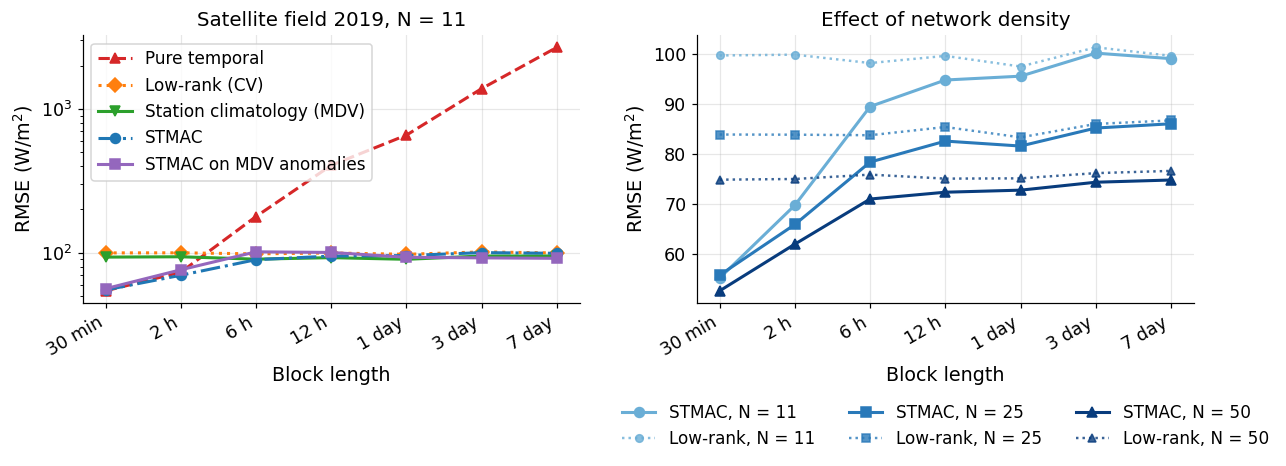

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(len(BLOCKS_SAT))
labs = [l for _, l in BLOCKS_SAT]
g11 = S11[S11.N == 11].set_index("block_len").loc[[b for b, _ in BLOCKS_SAT]]
for m, name, c, ls, mk in [("pure_temporal", "Pure temporal", "C3", "--", "^"),
                           ("softimpute_cv", "Low-rank (CV)", "C1", ":", "D"),
                           ("climatology", "Station climatology (MDV)", "C2", "-", "v"),
                           ("joint_longitude", "STMAC", "C0", "-.", "o"),
                           ("anomaly", "STMAC on MDV anomalies", "C4", "-", "s")]:
    if "rmse_" + m in g11:
        ax[0].plot(x, g11["rmse_" + m], ls, color=c, marker=mk, lw=2, ms=6.5, label=name)
ax[0].set_yscale("log")
ax[0].set_xticks(x); ax[0].set_xticklabels(labs, rotation=30, ha="right")
ax[0].set_xlabel("Block length"); ax[0].set_ylabel(r"RMSE (W/m$^2$)")
ax[0].set_title("Satellite field 2019, N = 11")
ax[0].legend(loc="upper left", frameon=True)
for n, c, mk in zip(N_LIST, [plt.cm.Blues(v) for v in (0.5, 0.72, 0.95)], ("o", "s", "^")):
    gn = S11[S11.N == n].set_index("block_len").loc[[b for b, _ in BLOCKS_SAT]]
    ax[1].plot(x, gn.rmse_joint_longitude, "-", color=c, marker=mk, lw=2, ms=6.5, label=f"STMAC, N = {n}")
    if "rmse_softimpute_cv" in gn:
        ax[1].plot(x, gn.rmse_softimpute_cv, ":", color=c, marker=mk, lw=1.6, ms=5, alpha=0.8,
                   label=f"Low-rank, N = {n}")
ax[1].set_xticks(x); ax[1].set_xticklabels(labs, rotation=30, ha="right")
ax[1].set_xlabel("Block length"); ax[1].set_ylabel(r"RMSE (W/m$^2$)")
ax[1].set_title("Effect of network density")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=False)
fig.tight_layout()
fig.savefig(RES / "E12_E11J_satellite.png")
plt.show()

In [28]:
CMP11 = load_csv("E11_comparability.csv")
print("INTERPRETASI JARINGAN SATELIT")
print("=" * 88)
if CMP11 is not None:
    c11 = CMP11.set_index("quantity")
    cor_o = c11.loc["mean inter-station correlation", "NLR_1999"]
    cor_n = c11.loc["mean inter-station correlation", "modern"]
    sd_ratio = c11.loc["clear-sky index sd", "modern"] / c11.loc["clear-sky index sd", "NLR_1999"]
    gate_ok = (sd_ratio >= 0.70) and (cor_n - cor_o <= 0.05)
    print(f"- Gate E11: rasio variabilitas {idn(sd_ratio, 3)}, korelasi antarstasiun {idn(cor_n, 3)} "
          f"lawan {idn(cor_o, 3)} (selisih {idn(cor_n - cor_o, 3)}). Status: "
          + ("lolos." if gate_ok else "gagal, sehingga hasil di bawah hanya pemeriksaan struktural."))
for n in N_LIST:
    gl = G11[(G11.N == n) & (G11.method == "joint_longitude")].iloc[0]
    txt = f"- N={n}: STMAC tumbuh {idn(gl.growth, 2)} kali (CI {idn(gl.ci_lo, 2)} sampai {idn(gl.ci_hi, 2)})"
    for m, nm in [("pure_temporal", "pure temporal"), ("softimpute_cv", "low-rank")]:
        q = G11[(G11.N == n) & (G11.method == m)]
        if len(q):
            txt += f", {nm} {idn(q.growth.iloc[0], 2)} kali"
    print(txt + ".")
ref11 = S11[S11.N == N_LIST[0]].set_index("block_len").rmse_joint_longitude
for n in N_LIST[1:]:
    cur = S11[S11.N == n].set_index("block_len").rmse_joint_longitude
    print(f"- Kepadatan N={n}: RMSE STMAC rata-rata turun {idn((1 - cur / ref11).mean() * 100)}% dibanding N=11.")
for n in N_LIST:
    s11 = S11[S11.N == n]
    print(f"- N={n}: rata-rata lintas blok STMAC {idn(s11.rmse_joint_longitude.mean())}, varian anomali "
          f"{idn(s11.rmse_anomaly.mean())}, klimatologi {idn(s11.rmse_climatology.mean())}, low-rank "
          f"{idn(s11.rmse_softimpute_cv.mean()) if 'rmse_softimpute_cv' in s11 else '-'} W/m2.")
    for a, b, nama in [("climatology", "joint_longitude", "STMAC vs klimatologi"),
                       ("climatology", "anomaly", "varian anomali vs klimatologi"),
                       ("softimpute_cv", "anomaly", "varian anomali vs low-rank")]:
        t = T11[(T11.N == n) & (T11.a == a) & (T11.b == b) & (T11.subset == "all")]
        if len(t):
            lead, trail = t[t.mean_diff > 0], t[t.mean_diff < 0]
            print(f"  {nama}: unggul {len(lead)}/{len(t)} ({int((lead.p_holm < 0.05).sum())} signifikan), "
                  f"tertinggal {len(trail)}/{len(t)} ({int((trail.p_holm < 0.05).sum())} signifikan).")
for n in N_LIST:
    lt = T11[(T11.N == n) & (T11.a == "joint_trivial") & (T11.subset == "all")]
    print(f"- N={n}: sheaf longitude vs trivial, selisih {idn(lt.mean_diff.min(), 2)} sampai "
          f"{idn(lt.mean_diff.max(), 2)} W/m2, signifikan di {int((lt.p_holm < 0.05).sum())}/{len(lt)} blok.")
    for subset, nama in [("all", "semua sel"), ("cloudy", "hari berawan")]:
        lr = T11[(T11.N == n) & (T11.a == "softimpute_cv") & (T11.b == "joint_longitude")
                 & (T11.subset == subset)]
        if len(lr):
            lead, trail = lr[lr.mean_diff > 0], lr[lr.mean_diff < 0]
            print(f"  vs low-rank ({nama}): STMAC unggul {len(lead)}/{len(lr)} "
                  f"({int((lead.p_holm < 0.05).sum())} signifikan), tertinggal {len(trail)}/{len(lr)} "
                  f"({int((trail.p_holm < 0.05).sum())} signifikan).")
for n in N_LIST:
    g_ = RAT11[RAT11.N == n]
    best = g_.loc[g_.rmse.idxmin()]
    fixed = g_[g_.ratio == RATIO].rmse.iloc[0]
    print(f"- Rasio pada blok {mid_lab}, N={n}: terbaik r = {idn(best.ratio, 2)} ({idn(best.rmse)} W/m2); "
          f"r = 10 memberi {idn(fixed)} W/m2 (selisih {idn((fixed / best.rmse - 1) * 100, 2)}%).")

INTERPRETASI JARINGAN SATELIT
- Gate E11: rasio variabilitas 0,937, korelasi antarstasiun 0,888 lawan 0,768 (selisih 0,121). Status: gagal, sehingga hasil di bawah hanya pemeriksaan struktural.
- N=11: STMAC tumbuh 1,80 kali (CI 1,71 sampai 1,89), pure temporal 49,59 kali, low-rank 1,00 kali.
- N=25: STMAC tumbuh 1,55 kali (CI 1,50 sampai 1,59), pure temporal 49,02 kali, low-rank 1,03 kali.
- N=50: STMAC tumbuh 1,42 kali (CI 1,40 sampai 1,45), pure temporal 51,28 kali, low-rank 1,02 kali.
- Kepadatan N=25: RMSE STMAC rata-rata turun 10,4% dibanding N=11.
- Kepadatan N=50: RMSE STMAC rata-rata turun 19,2% dibanding N=11.
- N=11: rata-rata lintas blok STMAC 86,3, varian anomali 87,3, klimatologi 92,8, low-rank 99,4 W/m2.
  STMAC vs klimatologi: unggul 3/7 (2 signifikan), tertinggal 4/7 (4 signifikan).
  varian anomali vs klimatologi: unggul 4/7 (4 signifikan), tertinggal 3/7 (2 signifikan).
  varian anomali vs low-rank: unggul 5/7 (5 signifikan), tertinggal 2/7 (0 signifikan).
- N=25: ra

## 9. Waktu komputasi terhadap jumlah stasiun (E8)

Kita memakai generator jaringan sintetis E8 dengan konstanta awan yang tertulis di notebook E8
($\beta$ = 1,2 dan 0,5). Hasil E8 yang tersimpan (`E8_multiscale_raw_uncalibrated.csv`) ternyata
dihasilkan dengan $\beta$ = 6,0 dan 1,2; sel pertama di bawah memeriksa hal itu dengan mereproduksi
satu baris tersimpan. Waktu solver gabungan diukur pada blok 3 hari, seed 0, untuk N = 11, 25, 50,
dan 100.

beta = (6.0, 1.2): solver lama, N=11, seed 0, 30 min = 93.495622 (tersimpan 93.495622)
beta = (1.2, 0.5): solver lama, N=11, seed 0, 30 min = 198.495999 (tersimpan 93.495622)
N= 11 | gabungan  0.54 s | variabel 120,821 | pure temporal  1.46 s
N= 25 | gabungan  1.18 s | variabel 269,276 | pure temporal  3.30 s
N= 50 | gabungan  2.59 s | variabel 535,890 | pure temporal  6.73 s
N=100 | gabungan  5.77 s | variabel 1,069,702 | pure temporal 44.61 s
Eksponen terukur: {'sec_joint': 1.08, 'sec_build': 1.18, 'sec_solve': 1.21, 'sec_pure_temporal': 1.49, 'sec_legacy': 0.96}


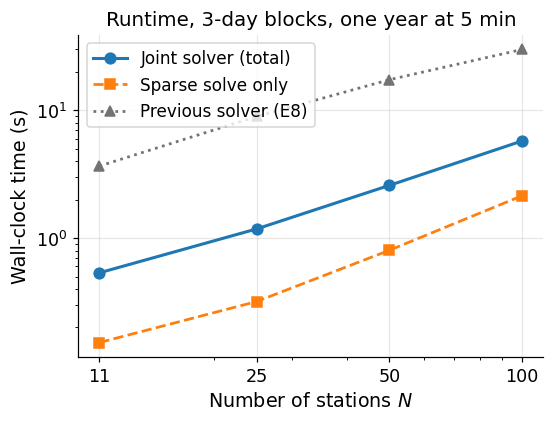

In [29]:
from scipy import special

DT_SYN, DAYS_SYN, BASE_SEED = 5, 365, 20260903
T_SYN = DAYS_SYN * 24 * 60 // DT_SYN
TIMES_SYN = pd.date_range("1999-01-01 00:05", periods=T_SYN, freq=f"{DT_SYN}min")


def solar_position(times_utc, lat_deg, lon_deg):
    doy = times_utc.dayofyear.values.astype(float)
    frac_hour = times_utc.hour.values + times_utc.minute.values / 60.0
    B = 2 * np.pi * (doy - 1) / 365.0
    decl = (0.006918 - 0.399912 * np.cos(B) + 0.070257 * np.sin(B) - 0.006758 * np.cos(2 * B)
            + 0.000907 * np.sin(2 * B) - 0.002697 * np.cos(3 * B) + 0.001480 * np.sin(3 * B))
    eot = 229.18 * (0.000075 + 0.001868 * np.cos(B) - 0.032077 * np.sin(B)
                    - 0.014615 * np.cos(2 * B) - 0.040849 * np.sin(2 * B))
    H = np.radians(15.0 * (frac_hour + lon_deg * 4.0 / 60.0 + eot / 60.0 - 12.0))
    phi = np.radians(lat_deg)
    return np.clip(np.sin(phi) * np.sin(decl) + np.cos(phi) * np.cos(decl) * np.cos(H), 0.0, None)


def haurwitz_e8(cosz):
    out = np.zeros_like(cosz); m = cosz > 1e-3
    out[m] = 1098.0 * cosz[m] * np.exp(-0.059 / cosz[m])
    return out


def advected_cloud_field(lats, lons, T_, dt_min, rng, corr_len_km=150.0, tau_min=45.0,
                         wind_kmh=35.0, wind_dir_deg=270.0, beta_a=1.2, beta_b=0.5):
    n = len(lats)
    Dm = ru.distance_matrix(lats, lons)
    theta = np.radians(wind_dir_deg)
    ux, uy = -np.sin(theta), -np.cos(theta)
    x_km = (lons - lons.mean()) * 111.0 * np.cos(np.radians(lats.mean()))
    y_km = (lats - lats.mean()) * 111.0
    lag = np.round(((x_km * ux + y_km * uy) / wind_kmh) * 60.0 / dt_min).astype(int)
    lag -= lag.min()
    T_ext = T_ + int(lag.max()) + 1
    A = np.linalg.cholesky(np.exp(-Dm ** 2 / (2.0 * corr_len_km ** 2)) + 1e-8 * np.eye(n))
    E = A @ rng.standard_normal((n, T_ext))
    phi = np.exp(-dt_min / tau_min)
    Z = np.empty((n, T_ext)); Z[:, 0] = E[:, 0]
    cc = np.sqrt(1.0 - phi ** 2)
    for t in range(1, T_ext):
        Z[:, t] = phi * Z[:, t - 1] + cc * E[:, t]
    Zl = np.stack([Z[i, lag[i]:lag[i] + T_] for i in range(n)])
    kt = stats.beta.ppf(np.clip(special.ndtr(Zl), 1e-6, 1 - 1e-6), beta_a, beta_b)
    return np.clip(kt, 0.03, 1.08)


def synth_network(n_st, seed, beta=(1.2, 0.5)):
    rng = np.random.default_rng(seed)
    if n_st == 11:
        lats, lons = LAT.copy(), LON.copy()
    else:
        lats = np.concatenate([LAT, rng.uniform(16.0, 30.0, max(0, n_st - N))])[:n_st]
        lons = np.concatenate([LON, rng.uniform(39.0, 50.0, max(0, n_st - N))])[:n_st]
    cosz = np.stack([solar_position(TIMES_SYN, la, lo) for la, lo in zip(lats, lons)])
    U_ = haurwitz_e8(cosz) * advected_cloud_field(lats, lons, T_SYN, DT_SYN, rng,
                                                  beta_a=beta[0], beta_b=beta[1])
    U_ += rng.normal(0.0, 2.0, U_.shape) * (cosz > 0)
    U_ = np.clip(U_, 0.0, None)
    _, L_, _ = ru.build_graph(lats, lons, 300.0, 3)
    return dict(U=U_, L=L_, delta=(lons - lons.mean()) / 15 * 60 / DT_SYN,
                day=cosz.max(axis=0) > 0.15)


L_TIME_SYN = sj.build_temporal_smoothness(T_SYN)
E8_OLD = load_csv("E8_multiscale_raw_uncalibrated.csv")
if E8_OLD is not None:
    ref8 = E8_OLD[(E8_OLD.N == 11) & (E8_OLD.seed == 0) & (E8_OLD.block_len == 6)].iloc[0]
    mask, _ = sj.build_block_mask(11, T_SYN, 6, 0.10, seed=0)
    for beta in [(6.0, 1.2), (1.2, 0.5)]:
        net8 = synth_network(11, BASE_SEED + 11, beta)
        ev = (~mask) & net8["day"][None, :]
        v8 = sj.rmse(net8["U"], sj.stmac_legacy(net8["U"], mask, net8["L"], L_TIME_SYN,
                                                net8["delta"], 4, 10.0, 1.0), ev)
        print(f"beta = {beta}: solver lama, N=11, seed 0, 30 min = {v8:.6f} "
              f"(tersimpan {ref8.rmse_stmac_longitude:.6f})")
    del net8

tm_rows = []
for n in [11, 25, 50, 100]:
    net8 = synth_network(n, BASE_SEED + n)
    mask, _ = sj.build_block_mask(n, T_SYN, 864, 0.10, seed=0)
    ev = (~mask) & net8["day"][None, :]
    secs = []
    for _ in range(3):
        U_r, info = sj.stmac_joint(net8["U"], mask, net8["L"], L_TIME_SYN, net8["delta"], None,
                                   ALPHA_T, ALPHA_S, return_info=True)
        secs.append(info["sec_total"])
    t0 = time.time(); sj.pure_temporal(net8["U"], mask, L_TIME_SYN, 10.0); t_pt = time.time() - t0
    tm_rows.append({"N": n, "sec_joint": float(np.median(secs)), "sec_build": info["sec_build"],
                    "sec_solve": info["sec_solve"], "n_unknowns": info["n_unknowns"], "nnz": info["nnz"],
                    "sec_pure_temporal": t_pt, "rmse_joint": sj.rmse(net8["U"], U_r, ev)})
    print(f"N={n:3d} | gabungan {np.median(secs):5.2f} s | variabel {info['n_unknowns']:,} | "
          f"pure temporal {t_pt:5.2f} s", flush=True)
    del net8, U_r
TM8 = pd.DataFrame(tm_rows)
OLD_SCALE = load_csv("E8_scaling.csv")
if OLD_SCALE is not None:
    TM8 = TM8.merge(OLD_SCALE[["N", "sec_stmac_longitude"]].rename(
        columns={"sec_stmac_longitude": "sec_legacy"}), on="N", how="left")
ru.atomic_csv(TM8, RES / "E12_E8J_scaling.csv")
EXP8 = {c: float(np.polyfit(np.log(TM8.N), np.log(TM8[c]), 1)[0])
        for c in ["sec_joint", "sec_build", "sec_solve", "sec_pure_temporal", "sec_legacy"] if c in TM8}
print("Eksponen terukur:", {k: round(v, 2) for k, v in EXP8.items()})

fig, ax = plt.subplots(figsize=(5.2, 4.0))
ax.loglog(TM8.N, TM8.sec_joint, "o-", lw=2, ms=7, label="Joint solver (total)")
ax.loglog(TM8.N, TM8.sec_solve, "s--", lw=1.8, ms=6, label="Sparse solve only")
if "sec_legacy" in TM8:
    ax.loglog(TM8.N, TM8.sec_legacy, "^:", color="0.45", lw=1.8, ms=6, label="Previous solver (E8)")
import matplotlib.ticker as mticker
ax.set_xticks(TM8.N.tolist())
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_xlabel("Number of stations $N$")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Runtime, 3-day blocks, one year at 5 min")
ax.legend(loc="upper left", frameon=True)
fig.tight_layout()
fig.savefig(RES / "E12_E8J_scaling.png")
plt.show()

In [30]:
print("INTERPRETASI WAKTU KOMPUTASI")
print("=" * 88)
for r in TM8.itertuples():
    print(f"- N={r.N}: solver gabungan {idn(r.sec_joint, 2)} detik untuk {idn(r.n_unknowns, 0)} variabel "
          f"(rakit {idn(r.sec_build, 2)} s, solve {idn(r.sec_solve, 2)} s).")
print(f"- Eksponen waktu total solver gabungan N^{idn(EXP8['sec_joint'], 2)} pada N = {TM8.N.min()} "
      f"sampai {TM8.N.max()}.")
if "sec_legacy" in EXP8:
    print(f"- Solver lama di E8: N^{idn(EXP8['sec_legacy'], 2)} (waktu ini sebagian besar dipakai langkah "
          "temporal yang hasilnya tertimpa).")
print("- Pengukuran memakai satu mesin dan satu mask; angka detik bergantung pada perangkat keras.")

INTERPRETASI WAKTU KOMPUTASI
- N=11: solver gabungan 0,54 detik untuk 120.821 variabel (rakit 0,15 s, solve 0,15 s).
- N=25: solver gabungan 1,18 detik untuk 269.276 variabel (rakit 0,31 s, solve 0,32 s).
- N=50: solver gabungan 2,59 detik untuk 535.890 variabel (rakit 0,66 s, solve 0,80 s).
- N=100: solver gabungan 5,77 detik untuk 1.069.702 variabel (rakit 2,08 s, solve 2,15 s).
- Eksponen waktu total solver gabungan N^1,08 pada N = 11 sampai 100.
- Solver lama di E8: N^0,96 (waktu ini sebagian besar dipakai langkah temporal yang hasilnya tertimpa).
- Pengukuran memakai satu mesin dan satu mask; angka detik bergantung pada perangkat keras.


## 10. Rangkuman angka

Sel ini mengumpulkan angka utama dari bagian 1 sampai 9 ke `E12_manuscript_numbers.csv` dan
menuliskan ringkasannya.

In [31]:
NUM = []


def put(section, key, value, note=""):
    NUM.append({"section": section, "key": key, "value": value, "note": note})


for r in S7.itertuples():
    for m in M7:
        put("E7J", f"rmse_{m}_{r.label}", getattr(r, m), f"CI {getattr(r, m + '_lo'):.1f}-{getattr(r, m + '_hi'):.1f}")
for r in G7.itertuples():
    put("E7J", f"growth_{r.method}", r.growth, f"CI {r.ci_lo:.2f}-{r.ci_hi:.2f}")
for r in T7.itertuples():
    put("E7J", f"diff_{r.a}_minus_{r.b}_{r.label}", r.mean_diff, f"wins {r.wins_b}/{r.n}, p_holm {r.p_holm:.2e}")
put("ratio", "r_cv_pooled", R_CV)
for bl, v in R_BLOCK.items():
    put("ratio", f"r_cv_{LABEL[bl]}", v)
for r in T_ho.itertuples():
    put("heldout", f"diff_{r.a}_minus_{r.b}_{r.label}", r.mean_diff, f"wins {r.wins_b}/{r.n}, p_holm {r.p_holm:.2e}")
for r in S_ho.itertuples():
    put("heldout", f"rmse_transformer_{r.label}", r.transformer)
    put("heldout", f"rmse_joint_r10_{r.label}", r.joint_r10)
put("E9J", "alignment_gain_joint_pooled", POOL["mean_gain"], f"wins {POOL['wins']}/{POOL['n']}, p {POOL['p']:.2e}")
for subset in S9:
    put("E9J", f"mean_joint_longitude_{subset}", S9[subset].joint_longitude.mean())
    put("E9J", f"mean_lowrank_raw_{subset}", S9[subset].lowrank_raw.mean())
for r in TAB2.itertuples():
    k = f"table2_{r.method}_{r.scenario}"
    put("econ", k + "_PT", r.PT); put("econ", k + "_TF", r.TF); put("econ", k + "_MDV", r.MDV)
    put("econ", k + "_STMAC", r.STMAC)
    put("econ", k + "_savings_vs_PT", r.savings_vs_PT)
    put("econ", k + "_savings_vs_TF", r.savings_vs_TF)
    put("econ", k + "_savings_vs_MDV", r.savings_vs_MDV)
for r in ECON[ECON.model == "A"].itertuples():
    put("econ", f"{r.method}_savings_vs_{r.baseline}_Conservative", r.savings_Conservative,
        f"g_base {r.g_base:.1f}, g_stmac {r.g_stmac:.1f}")
put("anomaly", "ratio", R_AN); put("anomaly", "ridge", G_AN)
for r in S_an.itertuples():
    put("anomaly", f"rmse_anomaly_{r.label}", r.anomaly, f"CI {r.anomaly_lo:.1f}-{r.anomaly_hi:.1f}")
    put("anomaly", f"rmse_climatology_{r.label}", r.climatology, f"CI {r.climatology_lo:.1f}-{r.climatology_hi:.1f}")
for r in T_an.itertuples():
    put("anomaly", f"diff_{r.a}_minus_{r.b}_{r.label}", r.mean_diff, f"wins {r.wins_b}/{r.n}, p_holm {r.p_holm:.2e}")
for r in G11.itertuples():
    put("E11J", f"growth_{r.method}_N{r.N}", r.growth)
for r in TM8.itertuples():
    put("E8J", f"sec_joint_N{r.N}", r.sec_joint)
put("E8J", "exponent_joint", EXP8["sec_joint"])
NUMS = pd.DataFrame(NUM)
ru.atomic_csv(NUMS, RES / "E12_manuscript_numbers.csv")
print(f"{len(NUMS)} angka disimpan ke E12_manuscript_numbers.csv")

s = S7.set_index("label")
tt = T7[(T7.a == "transformer") & (T7.b == "joint_longitude")]
ho = T_ho[(T_ho.a == "transformer") & (T_ho.b == "joint_r10")]
print()
print("RINGKASAN")
print("=" * 88)
print(f"1. Solver lama identik dengan interpolasi spasial per timestamp; alpha_t tidak berpengaruh "
      f"(selisih maksimum {inv:.1e}).")
print(f"2. Solver gabungan (r = 10): 30 min {idn(s.joint_longitude['30 min'])}, 6 h {idn(s.joint_longitude['6 h'])}, "
      f"3 day {idn(s.joint_longitude['3 day'])}, 7 day {idn(s.joint_longitude['7 day'])} W/m2; "
      f"pertumbuhan {idn(G7.set_index('method').growth['joint_longitude'], 2)} kali.")
print(f"3. Terhadap Transformer setahun penuh, STMAC unggul signifikan di "
      f"{int(((tt.mean_diff > 0) & (tt.p_holm < 0.05)).sum())} dari {len(tt)} panjang blok dan tertinggal "
      f"signifikan di {int(((tt.mean_diff < 0) & (tt.p_holm < 0.05)).sum())}.")
print(f"4. Pada periode uji ({HO.seed.nunique()} realisasi), STMAC unggul signifikan di "
      f"{int(((ho.mean_diff > 0) & (ho.p_holm < 0.05)).sum())} blok, tertinggal signifikan di "
      f"{int(((ho.mean_diff < 0) & (ho.p_holm < 0.05)).sum())} blok, tidak berbeda di "
      f"{int((ho.p_holm >= 0.05).sum())} blok.")
print(f"5. Rasio hasil validasi silang blok: r = {idn(R_CV, 0)}.")
t2 = TAB2[TAB2.method == "joint_longitude"]
print(f"6. Tabel II (STMAC, r = 10): penghematan terhadap PT {idn(t2.savings_vs_PT.min())} sampai "
      f"{idn(t2.savings_vs_PT.max())} juta USD/tahun; terhadap Transformer {idn(t2.savings_vs_TF.min())} "
      f"sampai {idn(t2.savings_vs_TF.max())}; terhadap klimatologi {idn(t2.savings_vs_MDV.min())} sampai "
      f"{idn(t2.savings_vs_MDV.max())}.")
cm = T7[(T7.a == "climatology") & (T7.b == "joint_longitude")]
print(f"7. Klimatologi stasiun lebih baik secara signifikan daripada STMAC di "
      f"{int(((cm.mean_diff < 0) & (cm.p_holm < 0.05)).sum())} dari {len(cm)} panjang blok; STMAC lebih baik "
      f"signifikan di {int(((cm.mean_diff > 0) & (cm.p_holm < 0.05)).sum())}.")
ca = T_an[T_an.a == "climatology"]
print(f"8. Varian anomali (r = {idn(R_AN, 0)}, ridge = {idn(G_AN, 1)}) lebih baik signifikan daripada "
      f"klimatologi di {int(((ca.mean_diff > 0) & (ca.p_holm < 0.05)).sum())} blok dan lebih buruk "
      f"signifikan di {int(((ca.mean_diff < 0) & (ca.p_holm < 0.05)).sum())} blok.")
print(f"9. Waktu solver gabungan tumbuh sekitar N^{idn(EXP8['sec_joint'], 2)} pada N = {TM8.N.min()} "
      f"sampai {TM8.N.max()}.")

273 angka disimpan ke E12_manuscript_numbers.csv

RINGKASAN
1. Solver lama identik dengan interpolasi spasial per timestamp; alpha_t tidak berpengaruh (selisih maksimum 0.0e+00).
2. Solver gabungan (r = 10): 30 min 114,3, 6 h 192,5, 3 day 202,3, 7 day 199,6 W/m2; pertumbuhan 1,75 kali.
3. Terhadap Transformer setahun penuh, STMAC unggul signifikan di 6 dari 7 panjang blok dan tertinggal signifikan di 1.
4. Pada periode uji (30 realisasi), STMAC unggul signifikan di 5 blok, tertinggal signifikan di 0 blok, tidak berbeda di 2 blok.
5. Rasio hasil validasi silang blok: r = 1.000.
6. Tabel II (STMAC, r = 10): penghematan terhadap PT 89,5 sampai 392,9 juta USD/tahun; terhadap Transformer 2,5 sampai 11,2; terhadap klimatologi -8,3 sampai -1,9.
7. Klimatologi stasiun lebih baik secara signifikan daripada STMAC di 6 dari 7 panjang blok; STMAC lebih baik signifikan di 1.
8. Varian anomali (r = 1.000, ridge = 3,0) lebih baik signifikan daripada klimatologi di 7 blok dan lebih buruk signifikan di